<a href="https://colab.research.google.com/github/nafanur/dataset_SindromOvarium/blob/main/PROJEK_BNSP_nafa_dataSO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## LIBRARY

In [ ]:
# library yg digunakan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import seaborn as sns

## 2.1 Pengambilan dan Integrasi Data

In [ ]:
# 1. Ambil data dari link https://drive.google.com/drive/folders/1SytprHcOKN9D7-v8_5YLtKWozvYnyZr2?usp=sharing
from google.colab import files
uploaded = files.upload()

Saving SOdata.xlsx to SOdata (1).xlsx


In [ ]:
dataSO = pd.read_excel("SOdata.xlsx")

# Tampilkan 5 baris pertama
dataSO.head()

,Sl. No,Patient File No.,SO (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,1,1,0,28,44.6,152.0,19.304017,15,78,22,...,1.0,0,110,80,3,3,18.0,18.0,8.5,NaN
1,2,2,0,36,65.0,161.5,24.921163,15,74,20,...,0.0,0,120,70,3,5,15.0,14.0,3.7,NaN
2,3,3,1,33,68.8,165.0,25.270891,11,72,18,...,1.0,0,120,80,13,15,18.0,20.0,10.0,NaN
3,4,4,0,37,65.0,148.0,29.674945,13,72,20,...,0.0,0,120,70,2,2,15.0,14.0,7.5,NaN
4,5,5,0,25,52.0,161.0,20.060954,11,72,18,...,0.0,0,120,80,3,4,16.0,14.0,7.0,NaN


In [ ]:
# Tampilkan ukuran data
print("Ukuran data :", dataSO.shape)

# informasi data
print(dataSO.info())

Ukuran data : (541, 45)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 45 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sl. No                  541 non-null    int64  
 1   Patient File No.        541 non-null    int64  
 2   SO (Y/N)                541 non-null    int64  
 3    Age (yrs)              541 non-null    int64  
 4   Weight (Kg)             541 non-null    float64
 5   Height(Cm)              541 non-null    float64
 6   BMI                     541 non-null    float64
 7   Blood Group             541 non-null    int64  
 8   Pulse rate(bpm)         541 non-null    int64  
 9   RR (breaths/min)        541 non-null    int64  
 10  Hb(g/dl)                541 non-null    float64
 11  Cycle(R/I)              541 non-null    int64  
 12  Cycle length(days)      541 non-null    int64  
 13  Marraige Status (Yrs)   540 non-null    float64
 14  Pregnant(Y/N)     

### 2. Rumuskan masalah apa yang akan dipecahkan sesuai dengan data yang diberikan. Manakah yang akan menjadi variabel dependen? Manakah yang akan menjadi variabel-variabel independen? Jelaskan alasannya!


Rumusan masalah: apakah karakteristik pasien yang meliputi faktor demografi, antropometri, kondisi klinis, hormonal, reproduksi, gaya hidup, serta karakteristik ovarium dapat digunakan untuk memprediksi status Sindrom Ovarium (SO).

Variabel dependen (Y): Variabel SO (Y/N) karena menunjukkan status pasien yang menjadi hasil atau kondisi yang ingin diprediksi, kode 1 untuk pasien yang mengalami SO dan 0 untuk pasien yang tidak mengalami SO.

Variabel independen (X):
1. karakteristik demografi yang meliputi Age (yrs), Blood Group, dan Marraige Status (Yrs);
2. karakteristik antropometri yang meliputi Weight (Kg), Height (Cm), BMI, Hip (inch), Waist (inch), dan Waist:Hip Ratio;
3. karakteristik klinis yang meliputi Pulse rate (bpm), RR (breaths/min), Hb (g/dl), Cycle (R/I), Cycle length (days), BP Systolic (mmHg), dan BP Diastolic (mmHg);
4. karakteristik hormonal dan pemeriksaan laboratorium yang meliputi I beta-HCG (mIU/mL), II beta-HCG (mIU/mL), FSH (mIU/mL), LH (mIU/mL), FSH/LH, TSH (mIU/L), AMH (ng/mL), PRL (ng/mL), Vit D3 (ng/mL), PRG (ng/mL), dan RBS (mg/dl);
5. karakteristik reproduksi yang meliputi Pregnant (Y/N) dan No. of aborptions;
6. karakteristik atau gejala fisik yang meliputi Weight gain (Y/N), hair growth (Y/N), Skin darkening (Y/N), Hair loss (Y/N), dan Pimples (Y/N);
7. karakteristik gaya hidup yang meliputi Fast food (Y/N) dan Reg.Exercise (Y/N)
8. karakteristik ovarium yang meliputi Follicle No. (L), Follicle No. (R), Avg. F size (L) (mm), Avg. F size (R) (mm), dan Endometrium (mm).

Variabel Sl. No dan Patient File No. tidak digunakan sebagai variabel independen karena keduanya hanya berfungsi sebagai identitas atau nomor pengenal pasien

### 3. Jelaskan tipe dan skala pengukuran dari setiap variabel dalam data yang diberikan.


1. **Sl. No**: nomor urut data atau pasien.
2. **Patient File No.**: nomor identitas atau nomor berkas pasien.
3. **SO (Y/N)**: status Sindrom Ovarium pada pasien.
4. **Age (yrs)**: usia pasien dalam tahun.
5. **Weight (Kg)**: berat badan pasien dalam kilogram.
6. **Height(Cm)**: tinggi badan pasien dalam sentimeter.
7. **BMI**: indeks massa tubuh yang dihitung berdasarkan berat dan tinggi badan.
8. **Blood Group**: golongan darah pasien.
9. **Pulse rate(bpm)**: frekuensi denyut nadi pasien per menit.
10. **RR (breaths/min)**: frekuensi pernapasan pasien per menit.
11. **Hb(g/dl)**: kadar hemoglobin dalam darah.
12. **Cycle(R/I)**: keteraturan siklus menstruasi.
13. **Cycle length(days)**: panjang siklus menstruasi dalam satuan hari.
14. **Marraige Status (Yrs)**: lama pernikahan dalam tahun.
15. **Pregnant(Y/N)**: status kehamilan pasien.
16. **No. of aborptions**: jumlah riwayat abortus pada pasien.
17. **I beta-HCG(mIU/mL)**: hasil pemeriksaan pertama beta-HCG.
18. **II beta-HCG(mIU/mL)**: hasil pemeriksaan kedua beta-HCG.
19. **FSH(mIU/mL)**: kadar *follicle-stimulating hormone*.
20. **LH(mIU/mL)**: kadar *luteinizing hormone*.
21. **FSH/LH**: rasio antara kadar FSH dan LH.
22. **Hip(inch)**: lingkar pinggul pasien.
23. **Waist(inch)**: lingkar pinggang pasien.
24. **Waist:Hip Ratio**: rasio antara lingkar pinggang dan lingkar pinggul.
25. **TSH (mIU/L)**: kadar *thyroid-stimulating hormone*.
26. **AMH(ng/mL)**: kadar *anti-Müllerian hormone*.
27. **PRL(ng/mL)**: kadar prolaktin.
28. **Vit D3 (ng/mL)**: kadar vitamin D3.
29. **PRG (ng/mL)**: kadar progesteron.
30. **RBS(mg/dl)**: kadar gula darah sewaktu.
31. **Weight gain(Y/N)**: ada atau tidaknya peningkatan berat badan.
32. **hair growth(Y/N)**: ada atau tidaknya pertumbuhan rambut berlebih.
33. **Skin darkening (Y/N)**: ada atau tidaknya penggelapan kulit.
34. **Hair loss(Y/N)**: ada atau tidaknya kerontokan rambut.
35. **Pimples(Y/N)**: ada atau tidaknya jerawat.
36. **Fast food (Y/N)**: kebiasaan mengonsumsi makanan cepat saji.
37. **Reg.Exercise(Y/N)**: kebiasaan melakukan olahraga secara rutin.
38. **BP _Systolic (mmHg)**: tekanan darah sistolik.
39. **BP _Diastolic (mmHg)**: tekanan darah diastolik.
40. **Follicle No. (L)**: jumlah folikel pada ovarium kiri.
41. **Follicle No. (R)**: jumlah folikel pada ovarium kanan.
42. **Avg. F size (L) (mm)**: rata-rata ukuran folikel pada ovarium kiri dalam milimeter.
43. **Avg. F size (R) (mm)**: rata-rata ukuran folikel pada ovarium kanan dalam milimeter.
44. **Endometrium (mm)**: ketebalan endometrium dalam milimeter.


In [ ]:
# Tipe data
tipe_dataSO = pd.DataFrame({
    "Variabel": dataSO.columns,
    "Tipe Data Python": dataSO.dtypes.astype(str).values
})

print(tipe_dataSO)

                  Variabel Tipe Data Python
0                   Sl. No            int64
1         Patient File No.            int64
2                 SO (Y/N)            int64
3                Age (yrs)            int64
4              Weight (Kg)          float64
5              Height(Cm)           float64
6                      BMI          float64
7              Blood Group            int64
8         Pulse rate(bpm)             int64
9         RR (breaths/min)            int64
10                Hb(g/dl)          float64
11              Cycle(R/I)            int64
12      Cycle length(days)            int64
13   Marraige Status (Yrs)          float64
14           Pregnant(Y/N)            int64
15       No. of aborptions            int64
16    I   beta-HCG(mIU/mL)          float64
17  II    beta-HCG(mIU/mL)           object
18             FSH(mIU/mL)          float64
19              LH(mIU/mL)          float64
20                  FSH/LH          float64
21               Hip(inch)      

In [ ]:
# hapus kolom terakhir
dataSO = dataSO.drop(columns=["Unnamed: 44"])

In [ ]:
# Perbaikan input data yang salah format
dataSO["II    beta-HCG(mIU/mL)"] = (
    dataSO["II    beta-HCG(mIU/mL)"]
    .astype(str)
    .str.strip()
    .replace({
        "1.99.": "1.99"
    })
)

# salah input di kolom "AMH"
dataSO["AMH(ng/mL)"] = (
    dataSO["AMH(ng/mL)"]
    .astype(str)
    .str.strip()
    .replace({
        "a": np.nan
    })
)

# ubah tipe data AMH
dataSO["AMH(ng/mL)"] = pd.to_numeric(
    dataSO["AMH(ng/mL)"],
    errors="coerce"
)

# ubah tipe data II    beta-HCG(mIU/mL)
dataSO["II    beta-HCG(mIU/mL)"] = pd.to_numeric(
    dataSO["II    beta-HCG(mIU/mL)"],
    errors="coerce"
)

#  salah input
dataSO.loc[dataSO['Cycle(R/I)'] == 5, 'Cycle(R/I)'] = np.nan

# Koreksi kesalahan entri data (bukan penghapusan baris)
dataSO.loc[dataSO['BP _Systolic (mmHg)'] == 12, 'BP _Systolic (mmHg)'] = 120       # hilang angka nol
dataSO.loc[dataSO['BP _Diastolic (mmHg)'] == 8, 'BP _Diastolic (mmHg)'] = 80        # hilang angka nol

In [ ]:
dataSO.columns = [c.strip() for c in dataSO.columns] # untuk menghilangkan spasi yang tidak diperlukan pada awal atau akhir nama kolom.
dataSO.columns

Index(['Sl. No', 'Patient File No.', 'SO (Y/N)', 'Age (yrs)', 'Weight (Kg)',
       'Height(Cm)', 'BMI', 'Blood Group', 'Pulse rate(bpm)',
       'RR (breaths/min)', 'Hb(g/dl)', 'Cycle(R/I)', 'Cycle length(days)',
       'Marraige Status (Yrs)', 'Pregnant(Y/N)', 'No. of aborptions',
       'I   beta-HCG(mIU/mL)', 'II    beta-HCG(mIU/mL)', 'FSH(mIU/mL)',
       'LH(mIU/mL)', 'FSH/LH', 'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio',
       'TSH (mIU/L)', 'AMH(ng/mL)', 'PRL(ng/mL)', 'Vit D3 (ng/mL)',
       'PRG(ng/mL)', 'RBS(mg/dl)', 'Weight gain(Y/N)', 'hair growth(Y/N)',
       'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)',
       'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'BP _Systolic (mmHg)',
       'BP _Diastolic (mmHg)', 'Follicle No. (L)', 'Follicle No. (R)',
       'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)', 'Endometrium (mm)'],
      dtype='object')

### 4. Jelaskan unit pengamatan (baris) dari data yang diberikan.

Dataset Sindrom Ovarium (SO) terdiri dari 541 unit pengamatan atau 541 pasien.

## 2.2 Deteksi missing value, apabila terdapat missing value, maka lakukan imputasi sesuai dengan tipe variabelnya

In [ ]:
# Deteksi missing value
missing_count = dataSO.isna().sum()

# Tampilkan hanya variabel yang memiliki missing value
missing_count = missing_count[missing_count > 0]

print("Jumlah missing value pada setiap variabel:")
display(missing_count)

Jumlah missing value pada setiap variabel:


,0
Cycle(R/I),1
Marraige Status (Yrs),1
AMH(ng/mL),1
Fast food (Y/N),1


In [ ]:
# ============================================================
# IMPUTASI MISSING VALUE
# Kategorik  -> Modus
# Numerik    -> Median karena tahan outlier
# ============================================================

# 1. Marraige Status (Yrs) - NUMERIK
col_numerik = "Marraige Status (Yrs)"
median_value = dataSO[col_numerik].median()
dataSO[col_numerik] = dataSO[col_numerik].fillna(median_value)
print(f"Median {col_numerik}: {median_value}")

# 2. AMH(ng/mL) - NUMERIK
median_amh = dataSO["AMH(ng/mL)"].median()
dataSO["AMH(ng/mL)"] = (dataSO["AMH(ng/mL)"].fillna(median_amh))
print("Median AMH(ng/mL):",median_amh)

# 3. Fast food (Y/N) - KATEGORIK
col_kategorik = "Fast food (Y/N)"
modus_value = dataSO[col_kategorik].mode()[0]
dataSO[col_kategorik] = dataSO[col_kategorik].fillna(modus_value)
print(f"Modus {col_kategorik}: {modus_value}")

# 4. CYCLE(R/I)
modus_cycle = dataSO["Cycle(R/I)"].mode()[0]
dataSO["Cycle(R/I)"] = dataSO["Cycle(R/I)"].fillna(
    modus_cycle)
print("Modus Cycle(R/I):", modus_cycle)

Median Marraige Status (Yrs): 7.0
Median AMH(ng/mL): 3.7
Modus Fast food (Y/N): 1.0
Modus Cycle(R/I): 2.0


## 2.3 IDENTIFIKASI DAN PENANGANAN DATA DUPLIKAT

In [ ]:
# Deteksi data duplikat, apabila terdapat data duplikat, maka lakukan penghapusan pada salah satu data yang sama
jumlah_duplikat = dataSO.duplicated().sum()
print("Jumlah data duplikat:", jumlah_duplikat)

Jumlah data duplikat: 0


## 2.4 IDENTIFIKASI DAN PENANGANAN PENCILAN

In [ ]:
# Deteksi pencilan, dilakukan pemeriksaan awal terhadap kemungkinan pencilan secara deskriptif. Jika ada pencilan lakukan penanganan.

numeric_cols = [
    "Age (yrs)",
    "Weight (Kg)",
    "Height(Cm)",
    "BMI",
    "Pulse rate(bpm)",
    "RR (breaths/min)",
    "Hb(g/dl)",
    "Cycle length(days)",
    "Marraige Status (Yrs)",
    "No. of aborptions",
    "I   beta-HCG(mIU/mL)",
    "II    beta-HCG(mIU/mL)",
    "FSH(mIU/mL)",
    "LH(mIU/mL)",
    "FSH/LH",
    "Hip(inch)",
    "Waist(inch)",
    "Waist:Hip Ratio",
    "TSH (mIU/L)",
    "AMH(ng/mL)",
    "PRL(ng/mL)",
    "Vit D3 (ng/mL)",
    "PRG(ng/mL)",
    "RBS(mg/dl)",
    "BP _Systolic (mmHg)",
    "BP _Diastolic (mmHg)",
    "Follicle No. (L)",
    "Follicle No. (R)",
    "Avg. F size (L) (mm)",
    "Avg. F size (R) (mm)",
    "Endometrium (mm)"
]

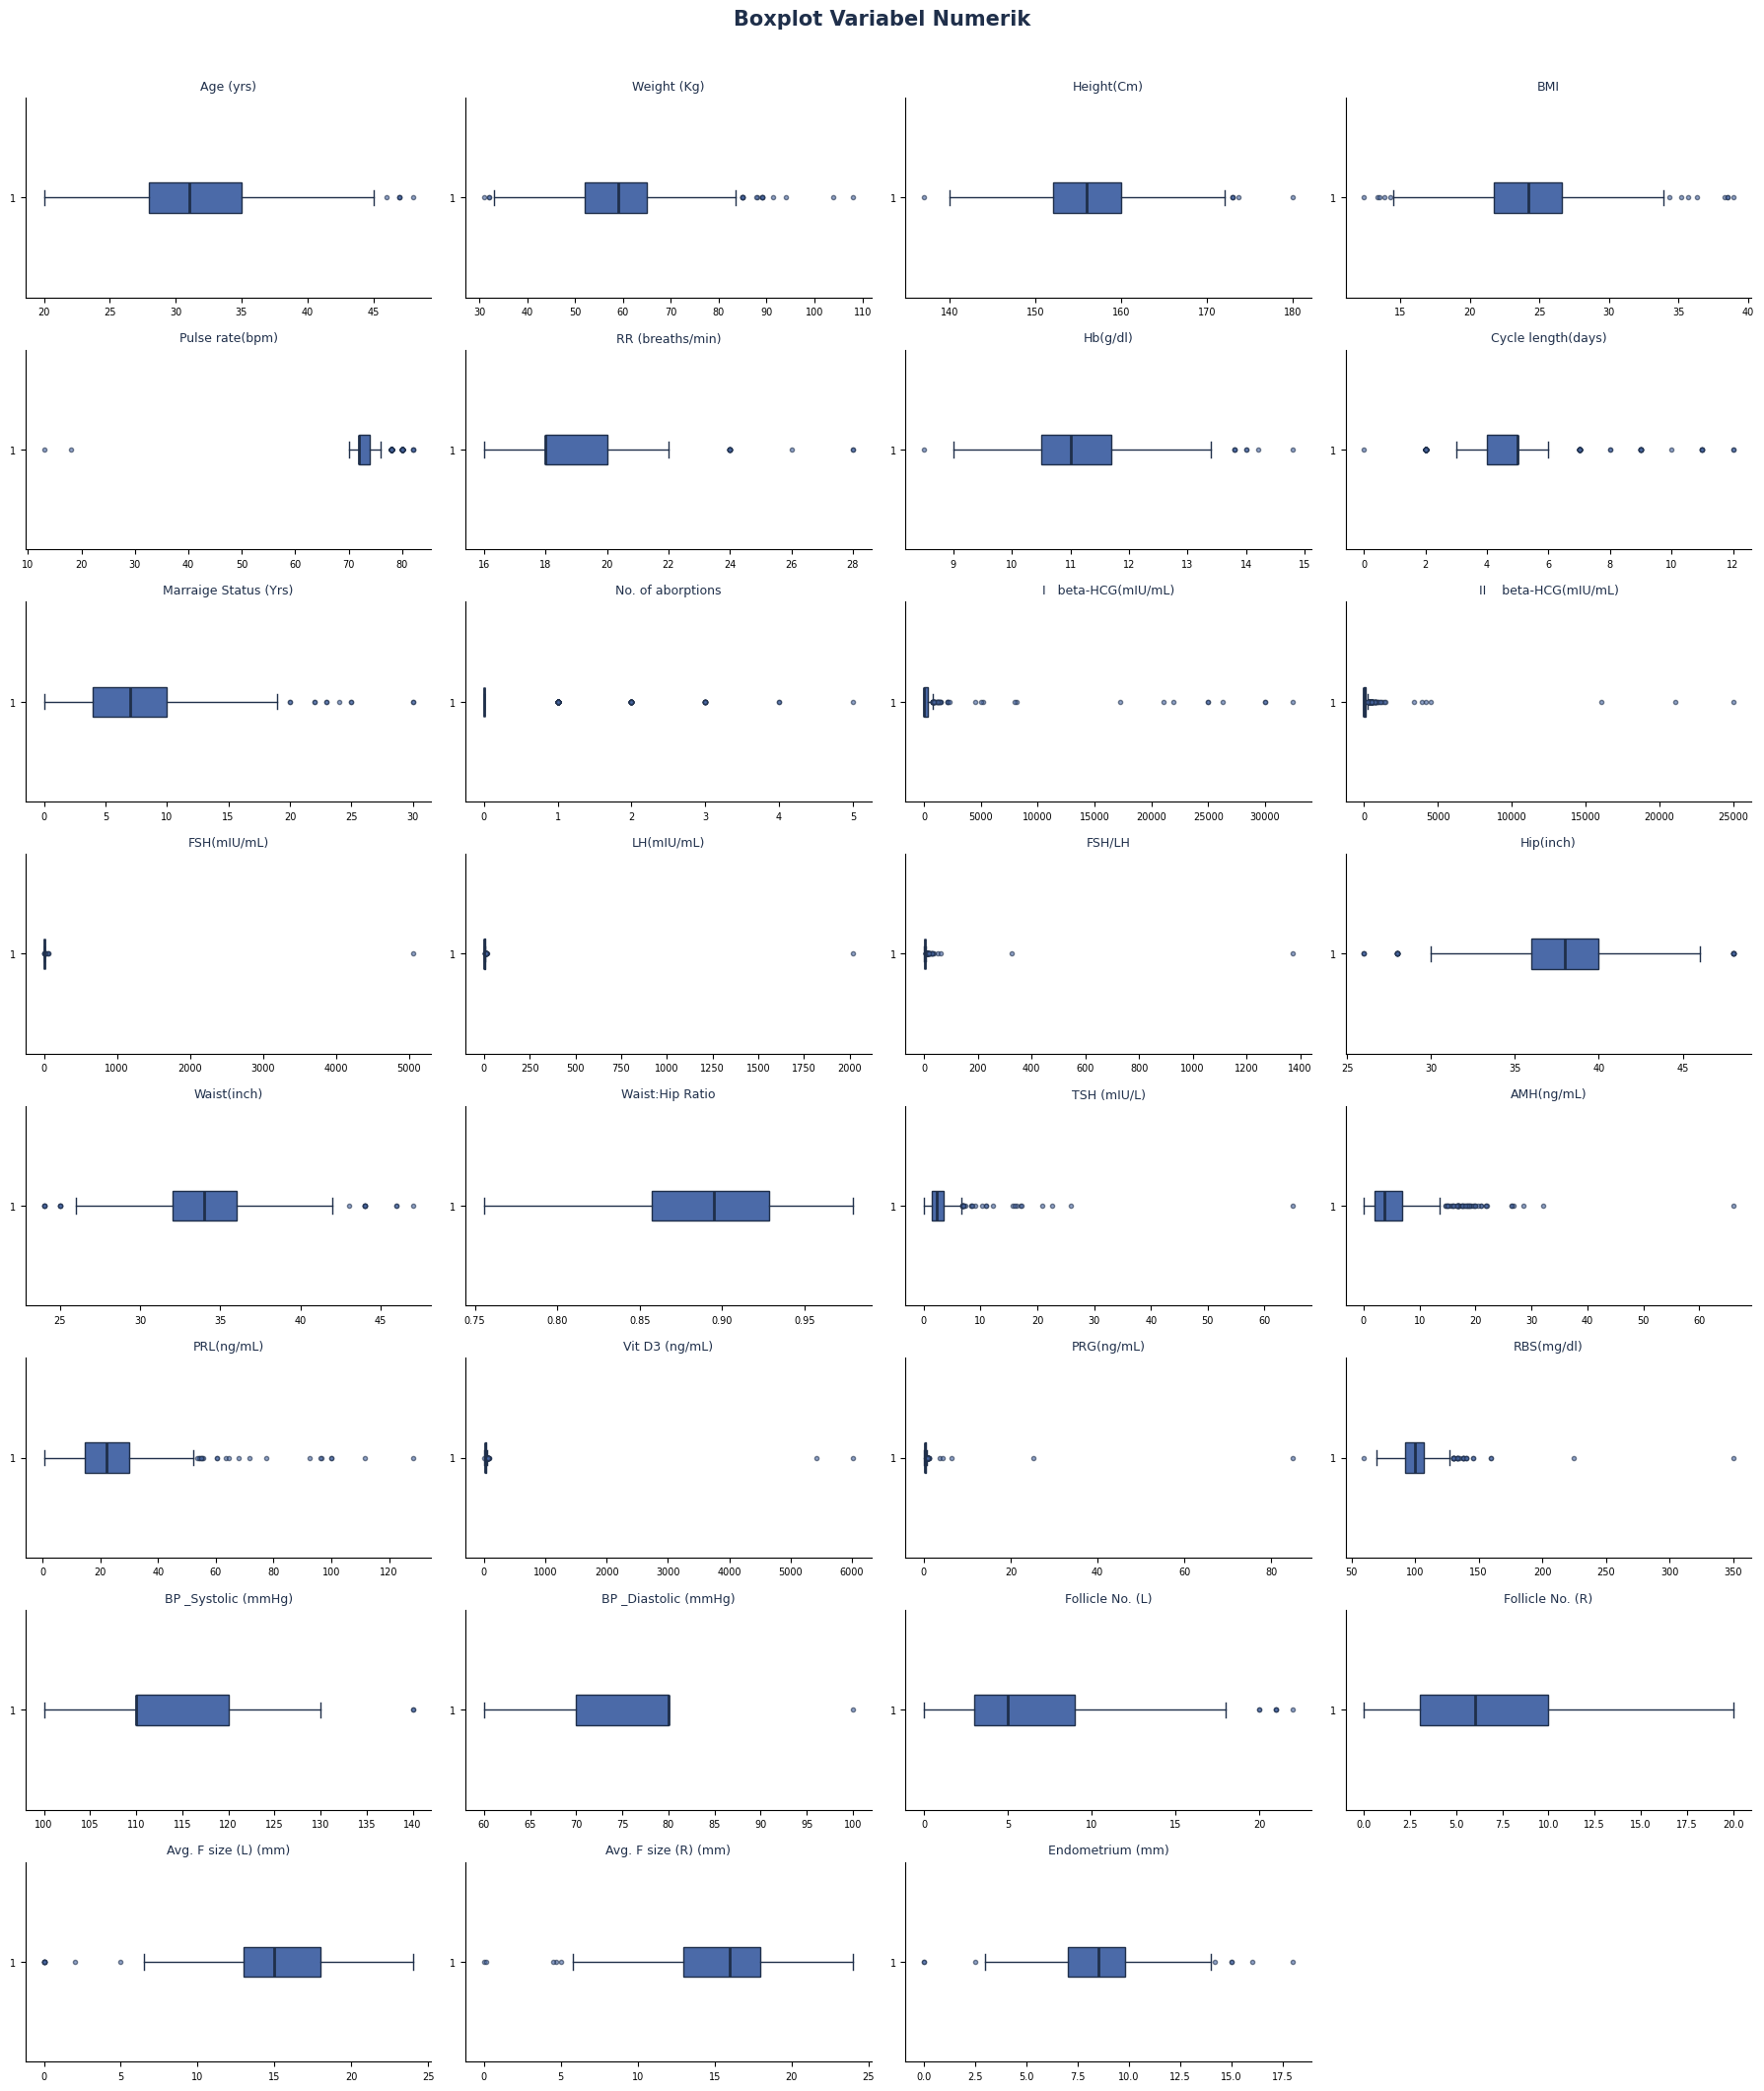

In [ ]:
# boxplot
# ============================================================
# BOXPLOT SELURUH VARIABEL NUMERIK - UNTUK PPT
# ============================================================

import matplotlib.pyplot as plt
import math

# Warna disesuaikan dengan template PPT
box_color = "#4B6AA8"
line_color = "#1F2F4A"

# 4 boxplot dalam 1 baris
n_cols = 4

# Jumlah baris otomatis
n_rows = math.ceil(
    len(numeric_cols) / n_cols
)

# Membuat satu figure
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, n_rows * 2.7),
    facecolor="white"
)

axes = axes.flatten()

for i, col in enumerate(numeric_cols):

    bp = axes[i].boxplot(
        dataSO[col].dropna(),
        vert=False,
        patch_artist=True,
        boxprops=dict(
            facecolor=box_color,
            edgecolor=line_color,
            linewidth=1
        ),
        whiskerprops=dict(
            color=line_color,
            linewidth=1
        ),
        capprops=dict(
            color=line_color,
            linewidth=1
        ),
        medianprops=dict(
            color=line_color,
            linewidth=2
        ),
        flierprops=dict(
            marker="o",
            markerfacecolor=box_color,
            markeredgecolor=line_color,
            markersize=3,
            alpha=0.6
        )
    )

    axes[i].set_title(
        col,
        fontsize=9,
        color=line_color
    )

    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

    axes[i].tick_params(
        axis="both",
        labelsize=7
    )

    # Border dibuat lebih halus
    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)

# Matikan subplot yang tidak terpakai
for j in range(
    len(numeric_cols),
    len(axes)
):
    axes[j].axis("off")

fig.suptitle(
    "Boxplot Variabel Numerik",
    fontsize=15,
    fontweight="bold",
    color=line_color
)

plt.tight_layout(
    rect=[0, 0, 1, 0.97]
)

plt.show()

In [ ]:
# DETEKSI OUTLIER DENGAN IQR
outlier_summary = []
for col in numeric_cols:
    Q1 = dataSO[col].quantile(0.25)
    Q3 = dataSO[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_mask = (
        (dataSO[col] < lower_bound) |
        (dataSO[col] > upper_bound)
    )

    jumlah_outlier = outlier_mask.sum()

    outlier_summary.append({
        "Variabel": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Batas Bawah": lower_bound,
        "Batas Atas": upper_bound,
        "Jumlah Outlier": jumlah_outlier
    })

outlier_summary = pd.DataFrame(outlier_summary)

display(outlier_summary)

,Variabel,Q1,Q3,IQR,Batas Bawah,Batas Atas,Jumlah Outlier
0,Age (yrs),28.000000,35.000000,7.000000,17.500000,45.500000,5
1,Weight (Kg),52.000000,65.000000,13.000000,32.500000,84.500000,18
2,Height(Cm),152.000000,160.000000,8.000000,140.000000,172.000000,6
3,BMI,21.707923,26.638918,4.930994,14.311432,34.035409,13
4,Pulse rate(bpm),72.000000,74.000000,2.000000,69.000000,77.000000,94
5,RR (breaths/min),18.000000,20.000000,2.000000,15.000000,23.000000,14
6,Hb(g/dl),10.500000,11.700000,1.200000,8.700000,13.500000,8
7,Cycle length(days),4.000000,5.000000,1.000000,2.500000,6.500000,77
8,Marraige Status (Yrs),4.000000,10.000000,6.000000,-5.000000,19.000000,11
9,No. of aborptions,0.000000,0.000000,0.000000,0.000000,0.000000,104


In [ ]:
# Tampilkan variabel yang memiliki outlier
outlier_ada = outlier_summary[
    outlier_summary["Jumlah Outlier"] > 0
]

display(outlier_ada)

,Variabel,Q1,Q3,IQR,Batas Bawah,Batas Atas,Jumlah Outlier
0,Age (yrs),28.000000,35.000000,7.000000,17.500000,45.500000,5
1,Weight (Kg),52.000000,65.000000,13.000000,32.500000,84.500000,18
2,Height(Cm),152.000000,160.000000,8.000000,140.000000,172.000000,6
3,BMI,21.707923,26.638918,4.930994,14.311432,34.035409,13
4,Pulse rate(bpm),72.000000,74.000000,2.000000,69.000000,77.000000,94
5,RR (breaths/min),18.000000,20.000000,2.000000,15.000000,23.000000,14
6,Hb(g/dl),10.500000,11.700000,1.200000,8.700000,13.500000,8
7,Cycle length(days),4.000000,5.000000,1.000000,2.500000,6.500000,77
8,Marraige Status (Yrs),4.000000,10.000000,6.000000,-5.000000,19.000000,11
9,No. of aborptions,0.000000,0.000000,0.000000,0.000000,0.000000,104


In [ ]:
# ============================================================
# PENANGANAN OUTLIER DENGAN CAPPING
# ============================================================

# Variabel yang tidak dilakukan capping
exclude_capping = [
    "No. of aborptions"
]

cap_summary = []

for col in numeric_cols:

    # Lewati No. of aborptions
    if col in exclude_capping:
        continue

    Q1 = dataSO[col].quantile(0.25)
    Q3 = dataSO[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Jumlah outlier sebelum capping
    outlier_before = (
        (dataSO[col] < lower_bound) |
        (dataSO[col] > upper_bound)
    ).sum()

    # Capping langsung ke dataSO
    dataSO[col] = dataSO[col].clip(
        lower=lower_bound,
        upper=upper_bound
    )

    cap_summary.append({
        "Variabel": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Batas Bawah": lower_bound,
        "Batas Atas": upper_bound,
        "Pencilan Sebelum": outlier_before
    })

cap_summary = pd.DataFrame(cap_summary)

display(cap_summary)

,Variabel,Q1,Q3,IQR,Batas Bawah,Batas Atas,Pencilan Sebelum
0,Age (yrs),28.000000,35.000000,7.000000,17.500000,45.500000,5
1,Weight (Kg),52.000000,65.000000,13.000000,32.500000,84.500000,18
2,Height(Cm),152.000000,160.000000,8.000000,140.000000,172.000000,6
3,BMI,21.707923,26.638918,4.930994,14.311432,34.035409,13
4,Pulse rate(bpm),72.000000,74.000000,2.000000,69.000000,77.000000,94
5,RR (breaths/min),18.000000,20.000000,2.000000,15.000000,23.000000,14
6,Hb(g/dl),10.500000,11.700000,1.200000,8.700000,13.500000,8
7,Cycle length(days),4.000000,5.000000,1.000000,2.500000,6.500000,77
8,Marraige Status (Yrs),4.000000,10.000000,6.000000,-5.000000,19.000000,11
9,I beta-HCG(mIU/mL),1.990000,297.210000,295.220000,-440.840000,740.040000,46


In [ ]:
# ============================================================
# CEK OUTLIER SETELAH CAPPING
# ============================================================

outlier_after = []

for col in numeric_cols:

    Q1 = dataSO[col].quantile(0.25)
    Q3 = dataSO[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_mask = (
        (dataSO[col] < lower_bound) |
        (dataSO[col] > upper_bound)
    )

    jumlah_outlier = outlier_mask.sum()

    outlier_after.append({
        "Variabel": col,
        "Batas Bawah": lower_bound,
        "Batas Atas": upper_bound,
        "Jumlah Outlier Setelah Capping": jumlah_outlier
    })

outlier_after = pd.DataFrame(outlier_after)

display(outlier_after)

,Variabel,Batas Bawah,Batas Atas,Jumlah Outlier Setelah Capping
0,Age (yrs),17.500000,45.500000,0
1,Weight (Kg),32.500000,84.500000,0
2,Height(Cm),140.000000,172.000000,0
3,BMI,14.311432,34.035409,0
4,Pulse rate(bpm),69.000000,77.000000,0
5,RR (breaths/min),15.000000,23.000000,0
6,Hb(g/dl),8.700000,13.500000,0
7,Cycle length(days),2.500000,6.500000,0
8,Marraige Status (Yrs),-5.000000,19.000000,0
9,No. of aborptions,0.000000,0.000000,104


In [ ]:
# outlier setelah capping
outlier_masih_ada = outlier_after[
    outlier_after["Jumlah Outlier Setelah Capping"] > 0
]

display(outlier_masih_ada)

,Variabel,Batas Bawah,Batas Atas,Jumlah Outlier Setelah Capping
9,No. of aborptions,0.0,0.0,104


### 8. Untuk variabel bertipe kategorik dengan nilai-nilainya berupa teks, lakukan proses encoding sehingga semuanya berbentuk numerik.

karena data nya sudah berbentuk numerik semua jadi tidak perlu encoding.


### 9. Hasil dari tahapan 5 sampai 8 sebut sebagai DATA BERSIH.

## 3.1 Analisis Statistika Deskriptif

### Untuk setiap variabel, lakukan analisis statistika deskriptif secara numerik dan grafik sesuai dengan tipe dan skala pengukuran dari DATA BERSIH.

In [ ]:
# Statistik deskriptif kategori numerik
deskriptif_numerik = pd.DataFrame({
    "N": dataSO[numeric_cols].count(),
    "Mean": dataSO[numeric_cols].mean(),
    "Median": dataSO[numeric_cols].median(),
    "Std Dev": dataSO[numeric_cols].std(),
    "Minimum": dataSO[numeric_cols].min(),
    "Q1": dataSO[numeric_cols].quantile(0.25),
    "Q3": dataSO[numeric_cols].quantile(0.75),
    "Maximum": dataSO[numeric_cols].max()
})

# Tambahkan IQR
deskriptif_numerik["IQR"] = (
    deskriptif_numerik["Q3"]
    - deskriptif_numerik["Q1"]
)

display(deskriptif_numerik.round(2))

,N,Mean,Median,Std Dev,Minimum,Q1,Q3,Maximum,IQR
Age (yrs),541,31.42,31.00,5.37,20.00,28.00,35.00,45.50,7.00
Weight (Kg),541,59.48,59.00,10.54,32.50,52.00,65.00,84.50,13.00
Height(Cm),541,156.47,156.00,5.95,140.00,152.00,160.00,172.00,8.00
BMI,541,24.28,24.24,3.90,14.31,21.71,26.64,34.04,4.93
Pulse rate(bpm),541,73.15,72.00,2.08,69.00,72.00,74.00,77.00,2.00
RR (breaths/min),541,19.20,18.00,1.54,16.00,18.00,20.00,23.00,2.00
Hb(g/dl),541,11.15,11.00,0.84,8.70,10.50,11.70,13.50,1.20
Cycle length(days),541,4.85,5.00,1.07,2.50,4.00,5.00,6.50,1.00
Marraige Status (Yrs),541,7.58,7.00,4.47,0.00,4.00,10.00,19.00,6.00
No. of aborptions,541,0.29,0.00,0.69,0.00,0.00,0.00,5.00,0.00


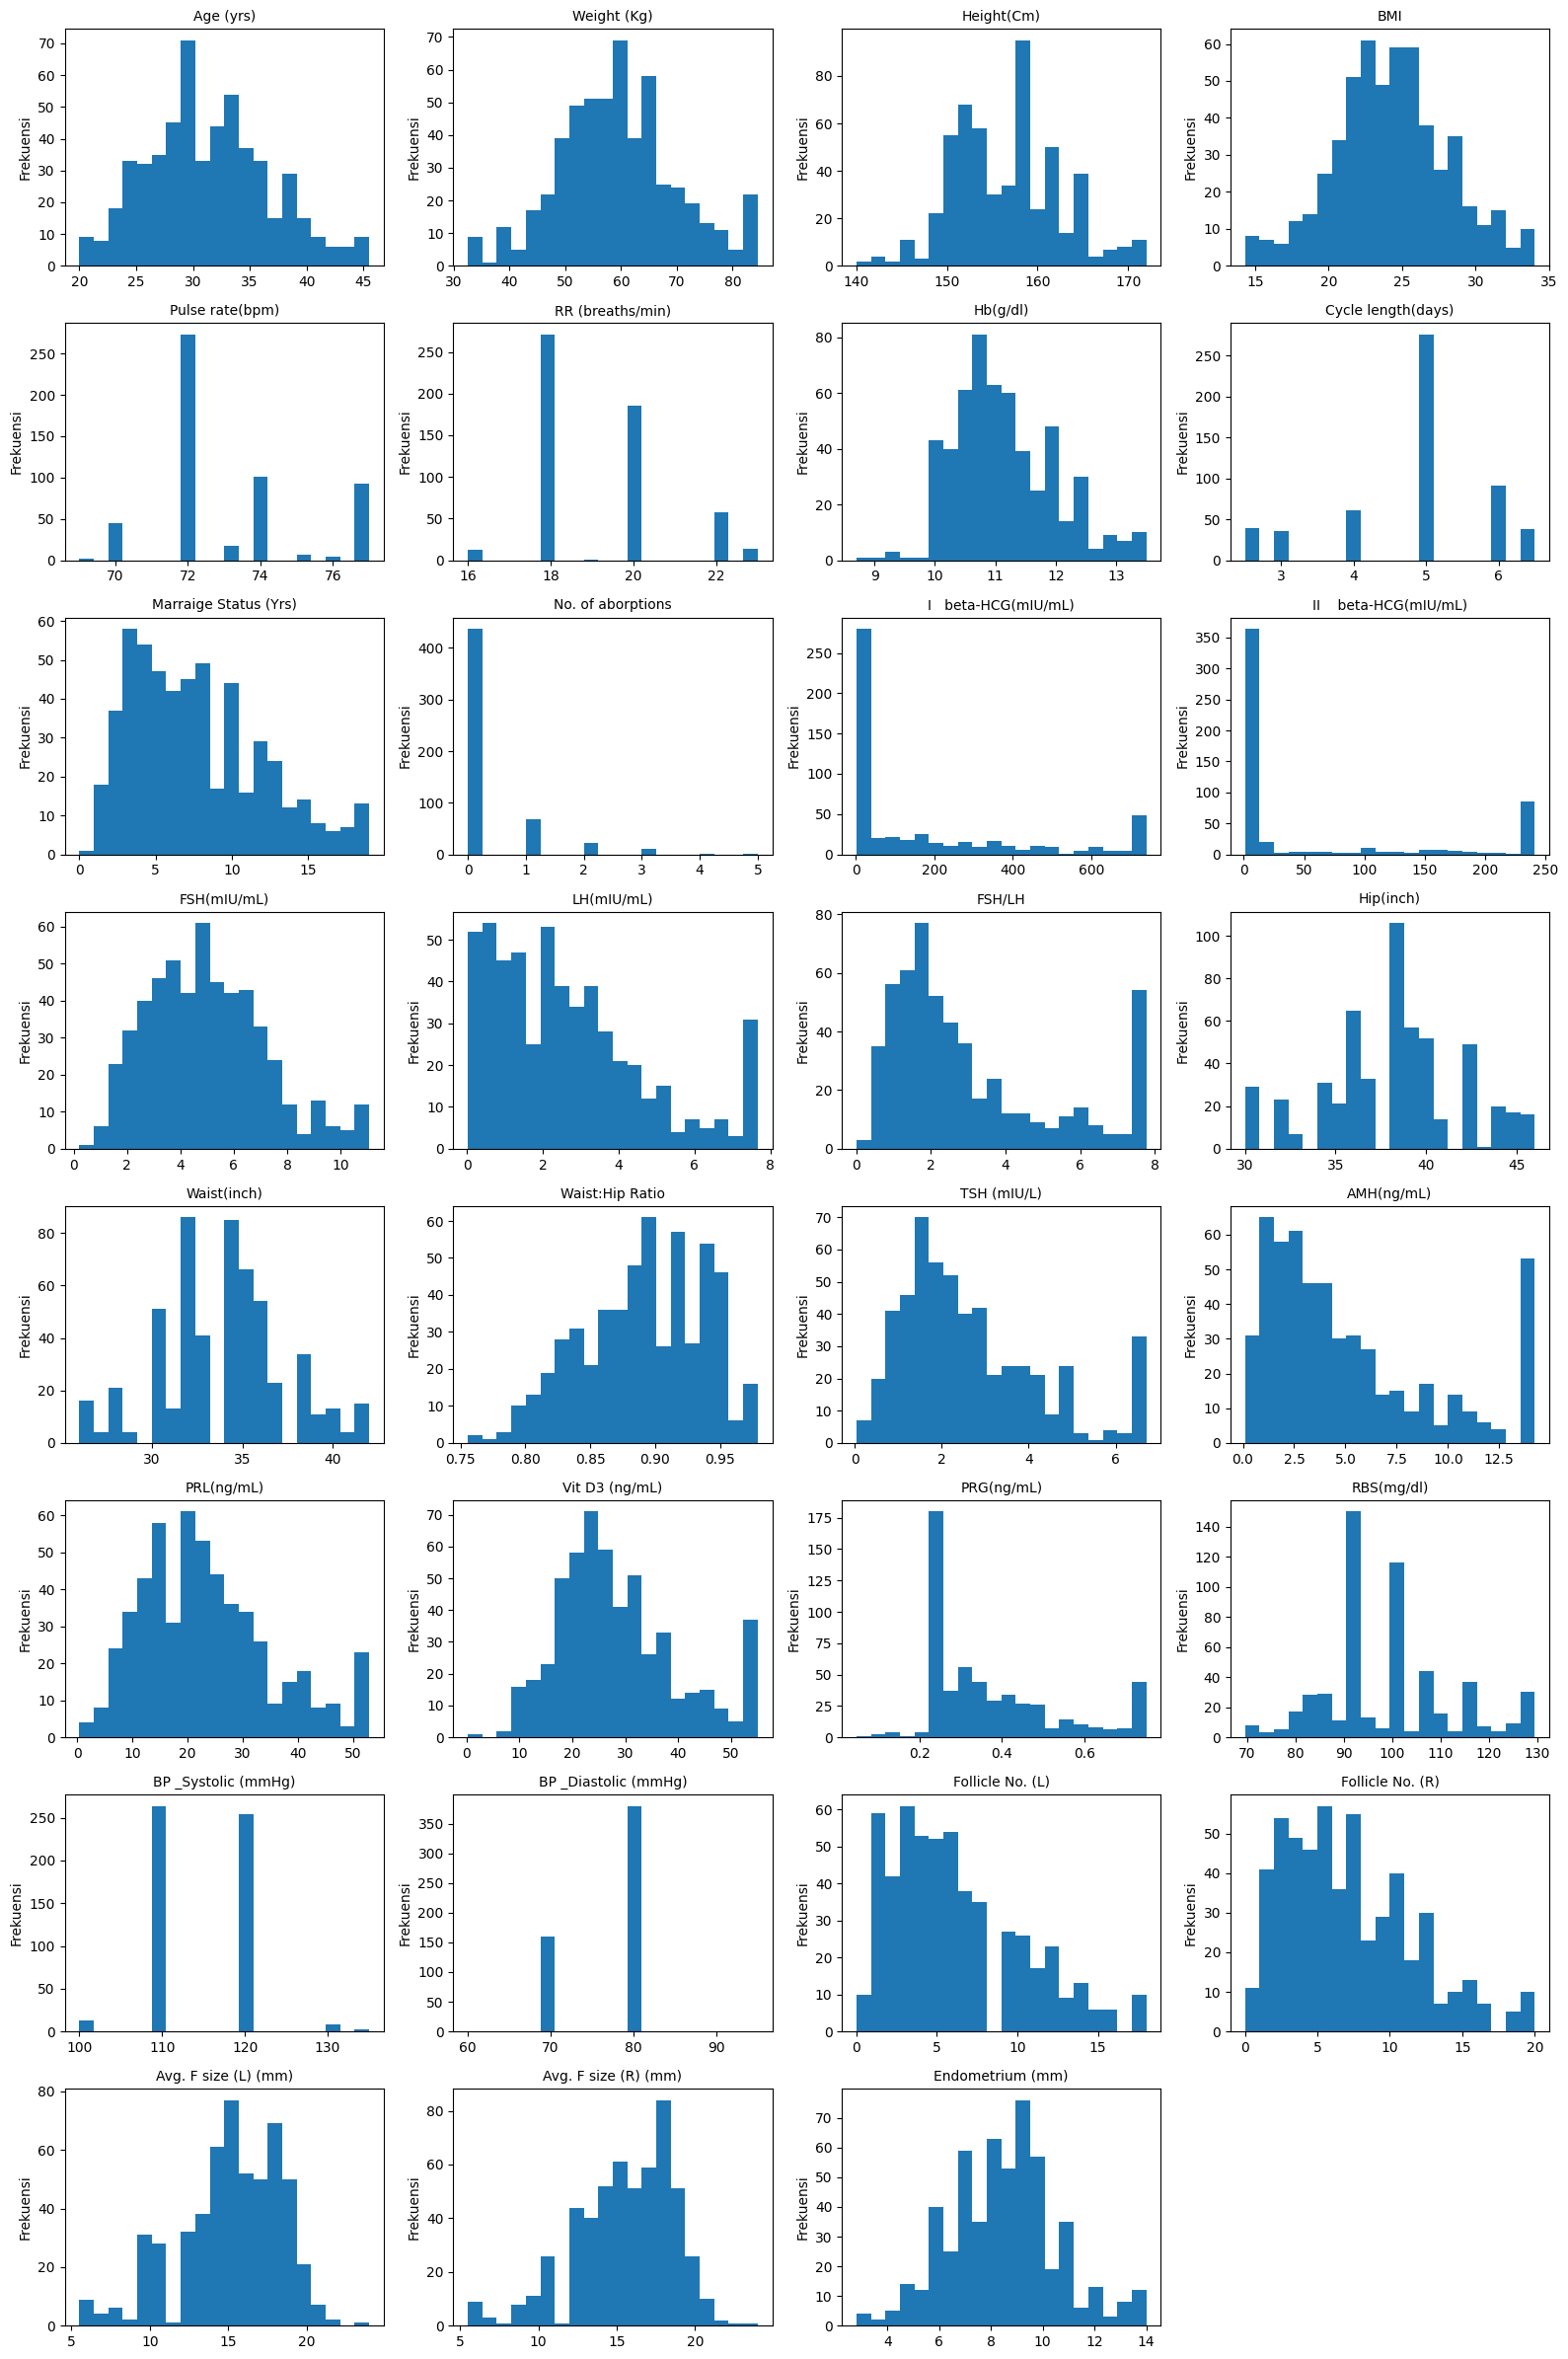

In [ ]:
# Histogram untuk setiap variabel numerik
# Jumlah kolom grafik per baris
n_cols = 4

# Hitung jumlah baris yang dibutuhkan
n_rows = math.ceil(len(numeric_cols) / n_cols)

# Buat satu figure
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, n_rows * 3)
)

# Ubah axes menjadi 1 dimensi
axes = axes.flatten()

# Buat histogram
for i, col in enumerate(numeric_cols):

    axes[i].hist(
        dataSO[col].dropna(),
        bins=20
    )

    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Frekuensi")

# Hapus subplot kosong
for i in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

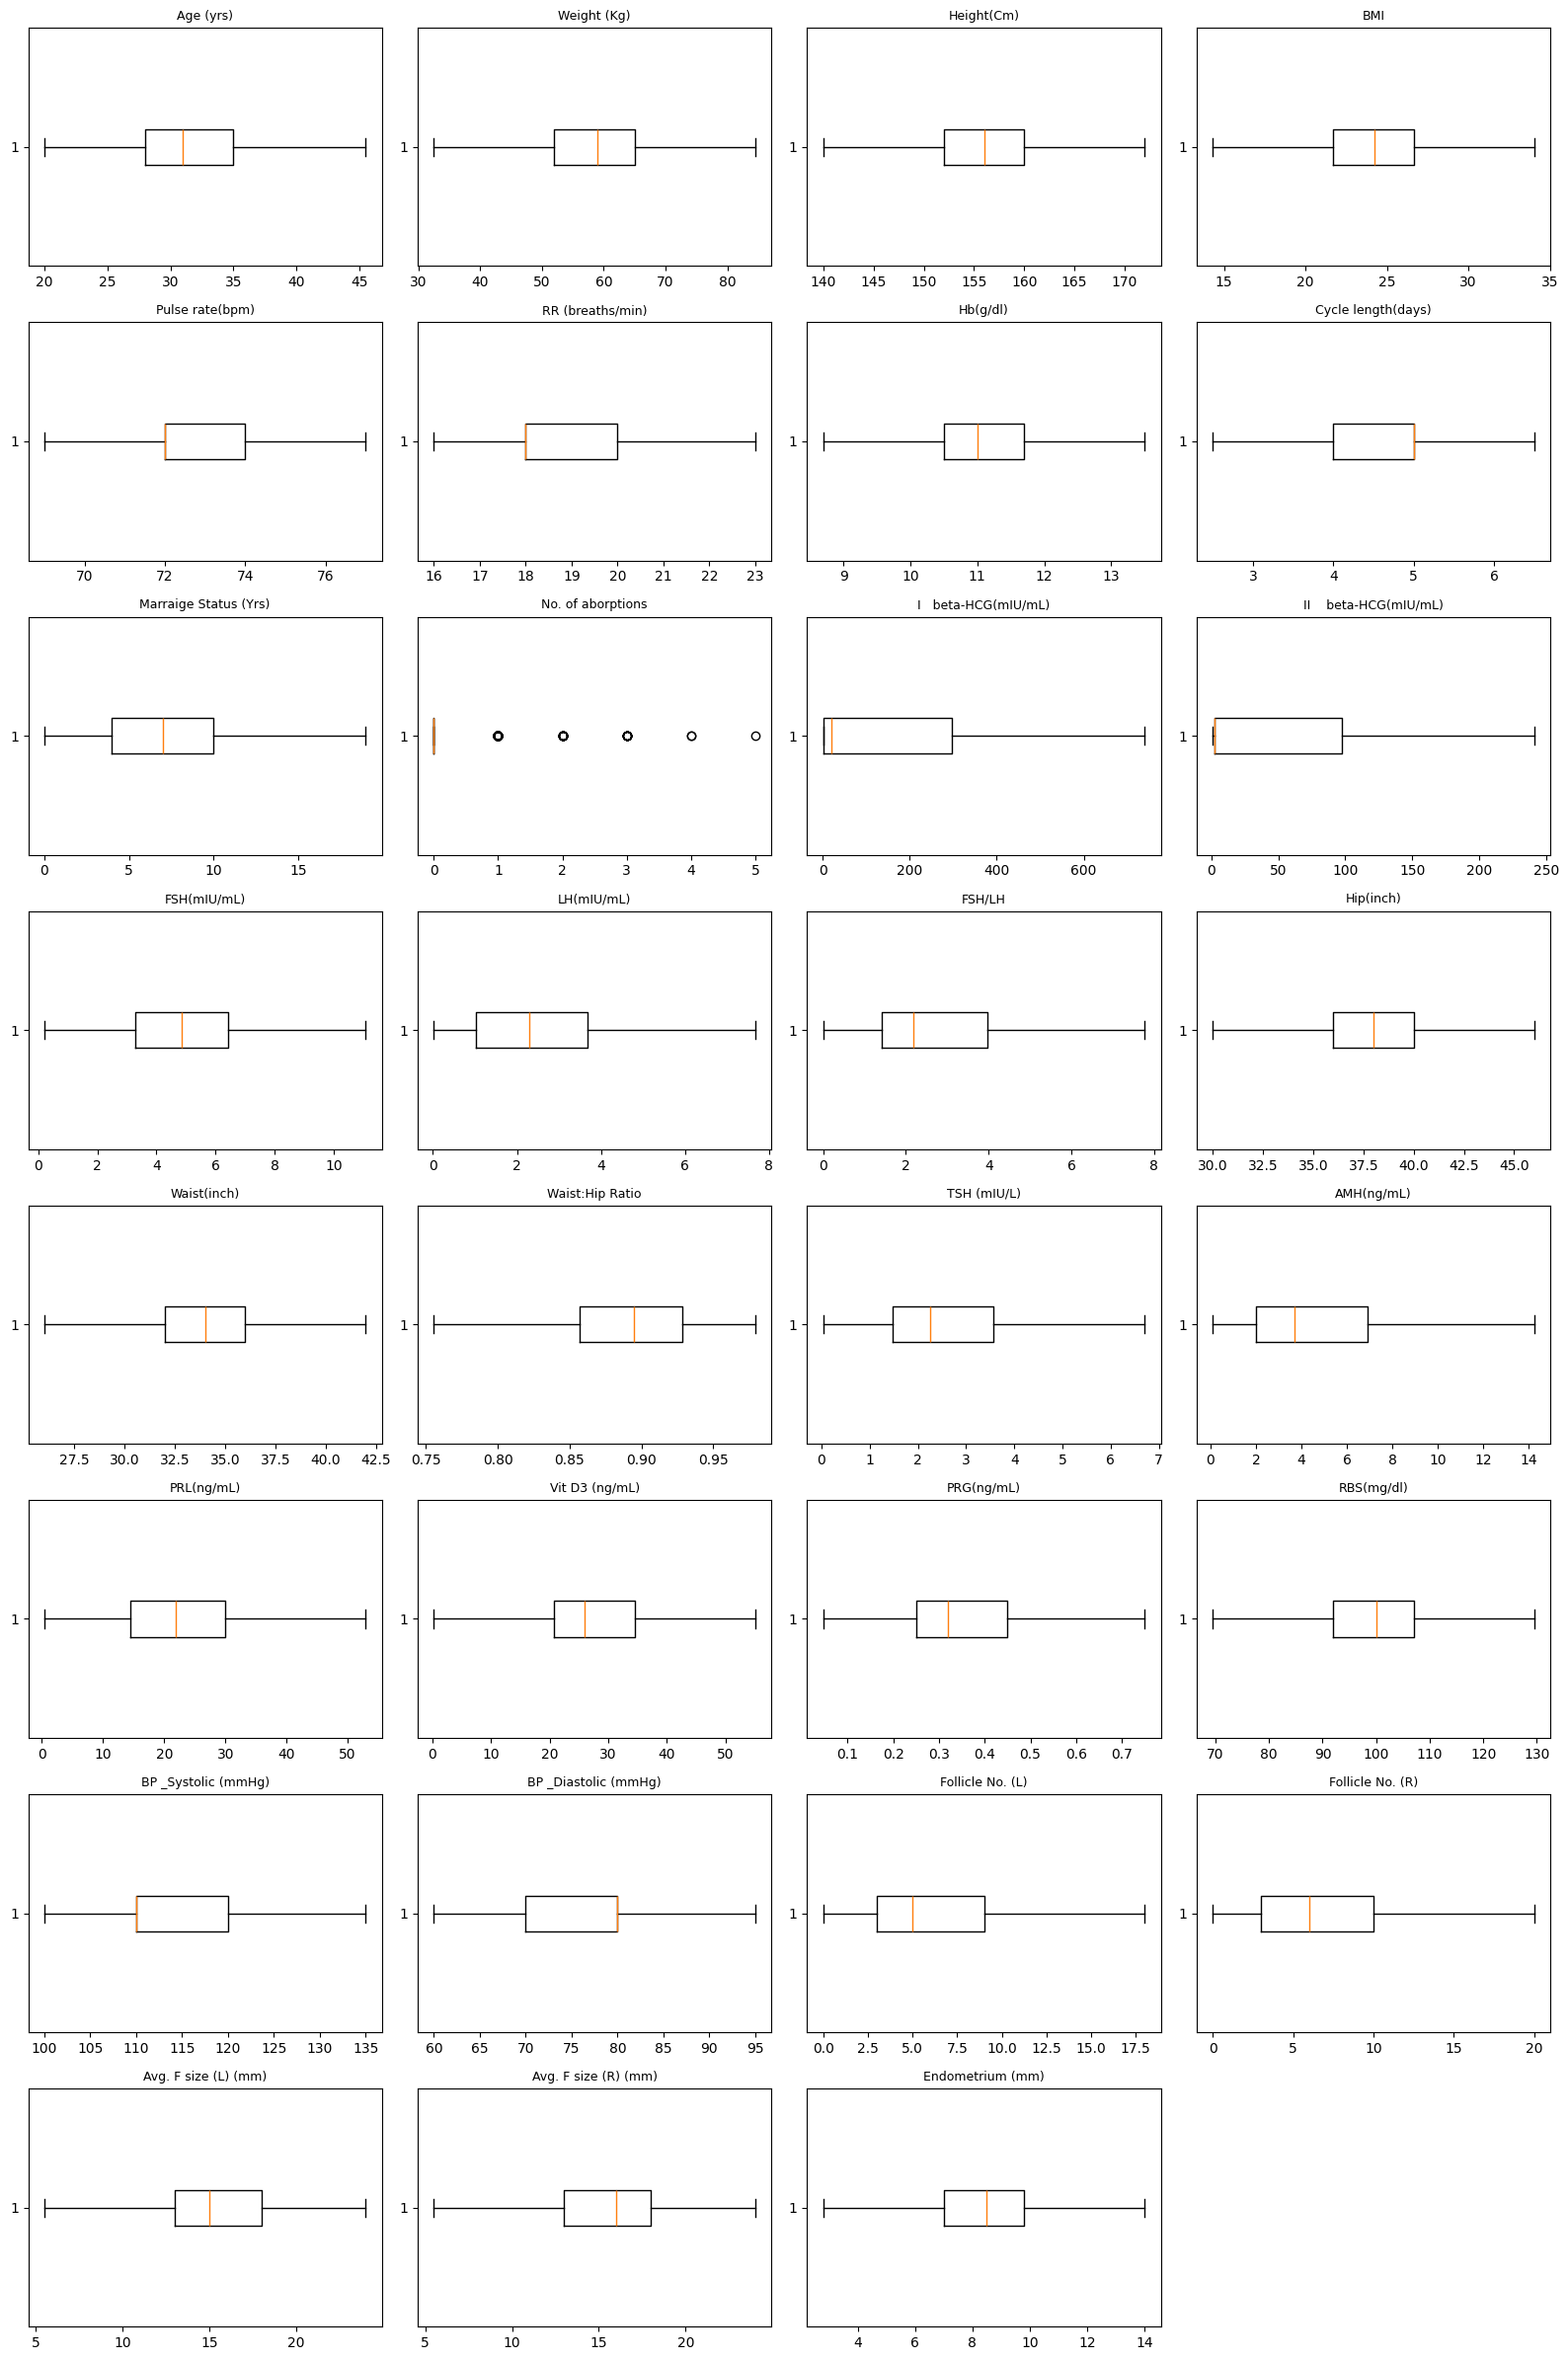

In [ ]:
# boxplot  UNTUK numerik

# Jumlah boxplot per baris
n_cols = 4

# Hitung jumlah baris secara otomatis
n_rows = math.ceil(len(numeric_cols) / n_cols)

# Buat subplot
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, n_rows * 3)
)

# Jika hanya 1 baris, ubah axes menjadi array
axes = axes.flatten()

# Membuat boxplot
for i, col in enumerate(numeric_cols):

    axes[i].boxplot(
        dataSO[col].dropna(),
        vert=False
    )

    axes[i].set_title(
        col,
        fontsize=9
    )

    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

# Matikan subplot yang tidak terpakai
for j in range(len(numeric_cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Statistik deskriptif untuk variabel kategorik
categorical_cols = [
    "Blood Group",
    "Cycle(R/I)",
    "Pregnant(Y/N)",
    "Weight gain(Y/N)",
    "hair growth(Y/N)",
    "Skin darkening (Y/N)",
    "Hair loss(Y/N)",
    "Pimples(Y/N)",
    "Fast food (Y/N)",
    "Reg.Exercise(Y/N)",
    "SO (Y/N)"
]

In [ ]:
deskriptif_kategorik = []
for col in categorical_cols:
    freq = dataSO[col].value_counts(
        dropna=False
    )
    persen = (
        dataSO[col]
        .value_counts(
            normalize=True,
            dropna=False
        ) * 100
    )

    for kategori in freq.index:
        deskriptif_kategorik.append({
            "Variabel": col,
            "Kategori": kategori,
            "Frekuensi": freq[kategori],
            "Persentase (%)": persen[kategori]
        })
deskriptif_kategorik = pd.DataFrame(
    deskriptif_kategorik
)

display(
    deskriptif_kategorik.round(2)
)

,Variabel,Kategori,Frekuensi,Persentase (%)
0,Blood Group,15.0,206,38.08
1,Blood Group,13.0,135,24.95
2,Blood Group,11.0,108,19.96
3,Blood Group,17.0,42,7.76
4,Blood Group,16.0,19,3.51
5,Blood Group,14.0,16,2.96
6,Blood Group,12.0,13,2.40
7,Blood Group,18.0,2,0.37
8,Cycle(R/I),2.0,391,72.27
9,Cycle(R/I),4.0,150,27.73


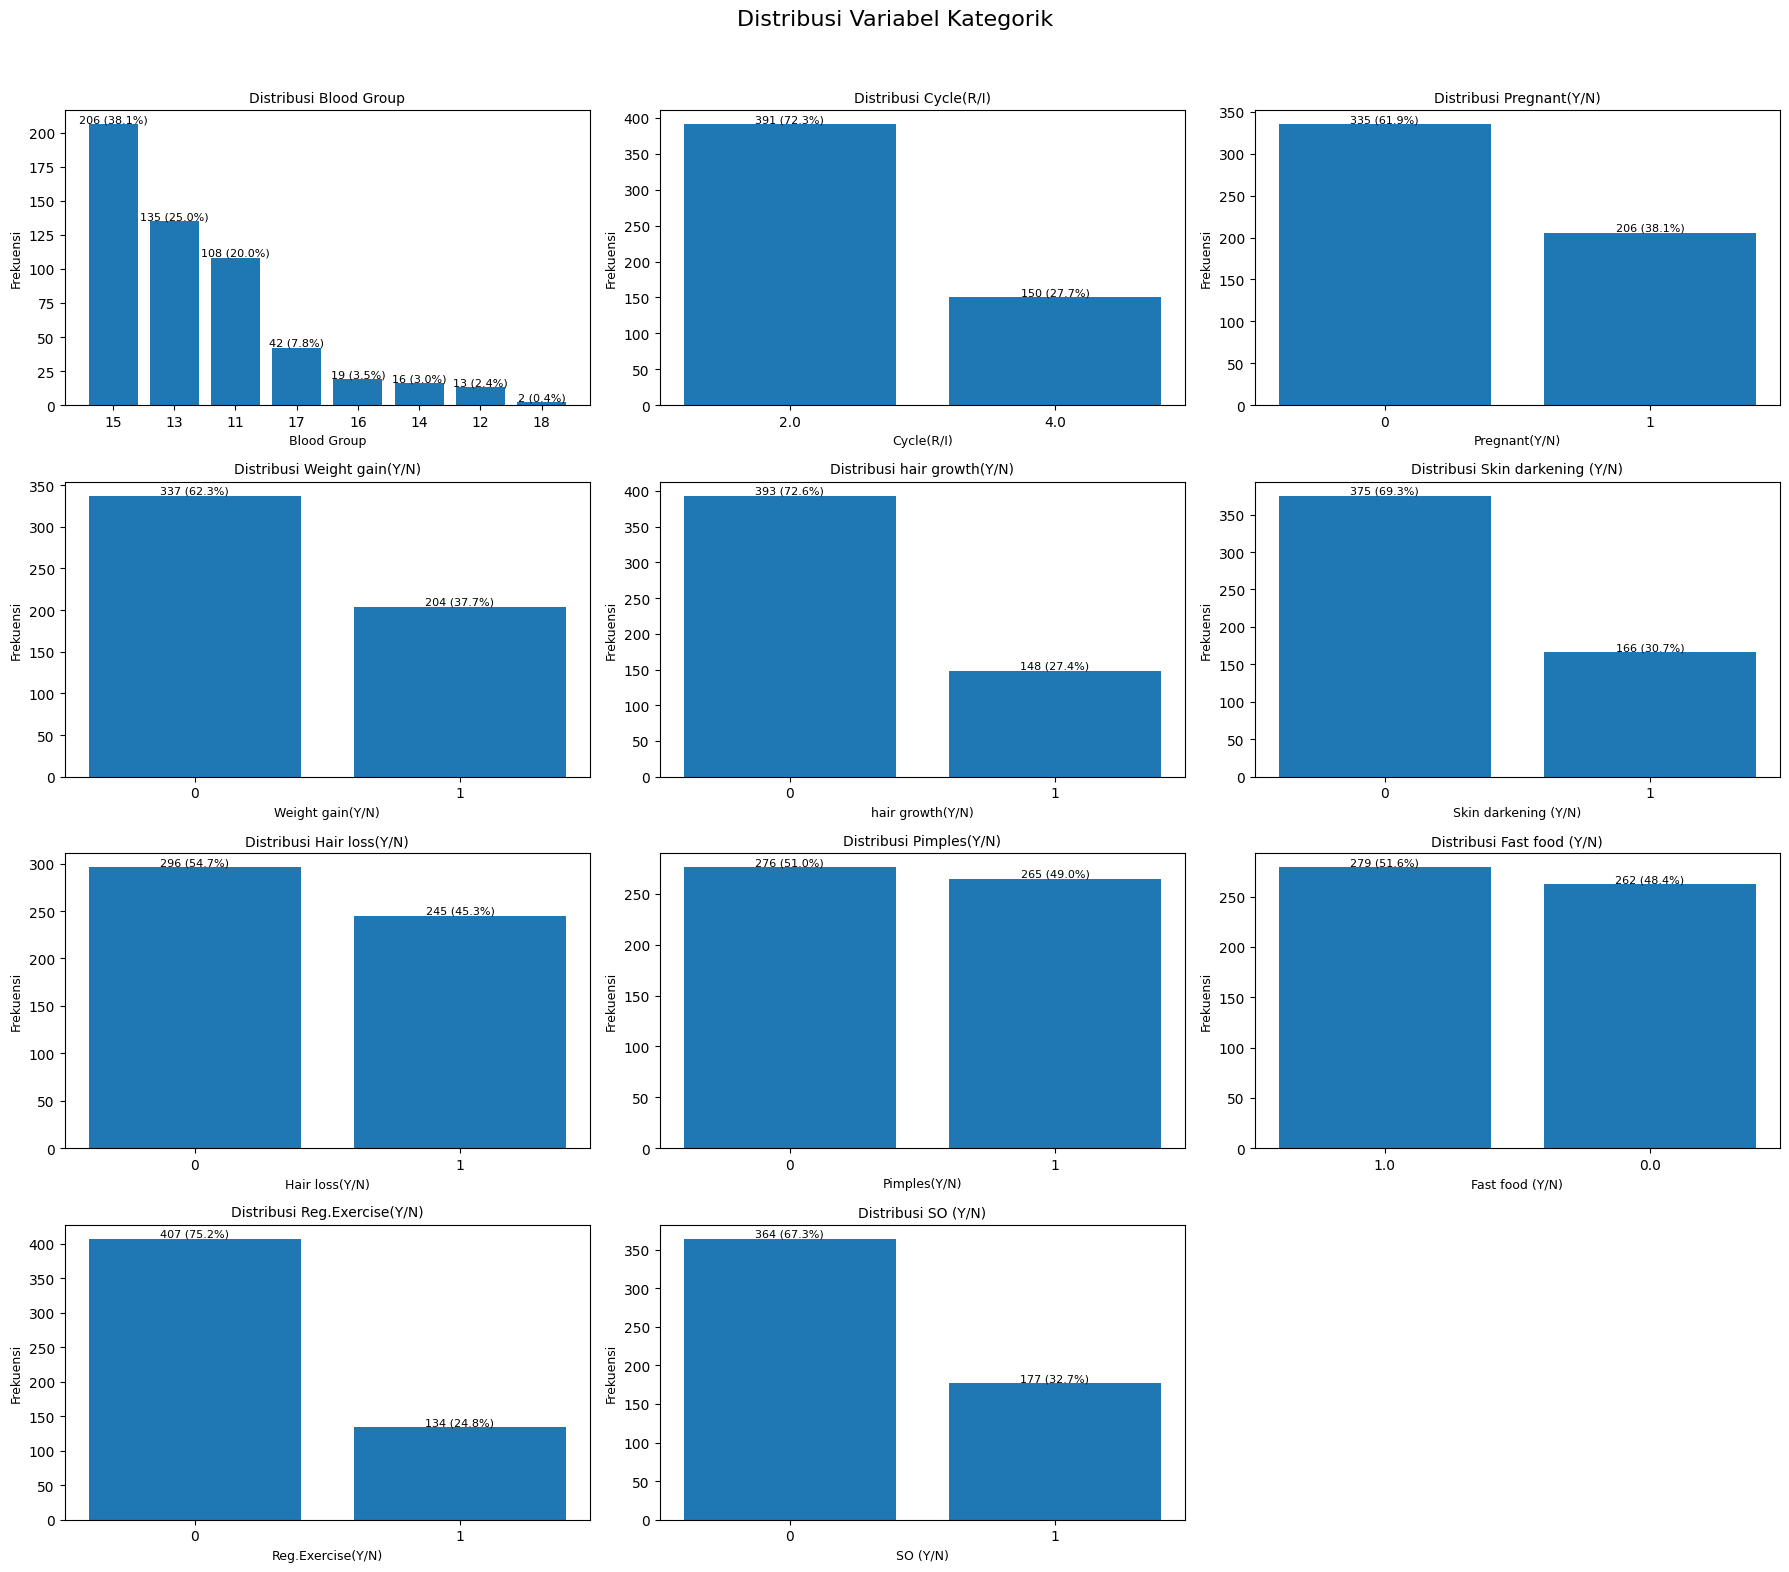

In [ ]:
# ============================================================
# BAR CHART VARIABEL KATEGORIK DALAM SATU LAYAR
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import math

# Jumlah kolom grafik
n_cols = 3

# Menghitung jumlah baris yang diperlukan
n_rows = math.ceil(len(categorical_cols) / n_cols)

# Membuat satu figure dengan beberapa subplot
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, n_rows * 4)
)

# Mengubah axes menjadi array satu dimensi
axes = np.array(axes).flatten()

# Membuat bar chart untuk setiap variabel
for i, col in enumerate(categorical_cols):

    # Menghitung frekuensi setiap kategori
    counts = dataSO[col].value_counts(
        dropna=False
    )

    # Menghitung persentase
    percentages = (
        counts / counts.sum() * 100
    )

    # Membuat bar chart
    bars = axes[i].bar(
        counts.index.astype(str),
        counts.values
    )

    # Judul dan label
    axes[i].set_title(
        f"Distribusi {col}",
        fontsize=10
    )

    axes[i].set_xlabel(
        col,
        fontsize=9
    )

    axes[i].set_ylabel(
        "Frekuensi",
        fontsize=9
    )

    # Menampilkan frekuensi dan persentase
    for bar, count, pct in zip(
        bars,
        counts.values,
        percentages.values
    ):

        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{int(count)} ({pct:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=8
        )

    # Memutar label sumbu X jika diperlukan
    axes[i].tick_params(
        axis="x",
        labelrotation=0
    )

# Mematikan subplot yang tidak digunakan
for j in range(
    len(categorical_cols),
    len(axes)
):
    axes[j].axis("off")

# Judul keseluruhan
plt.suptitle(
    "Distribusi Variabel Kategorik",
    fontsize=16
)

# Mengatur jarak antar grafik
plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

plt.show()

### 11. Untuk setiap variabel independen bertipe kategorik (skala pengukuran nominal atau ordinal), buatlah tabel kontingensi antara variabel independen tersebut dengan variabel dependennya. Bagaimana hubungan antara dua variabel tersebut?

In [ ]:
# ============================================================
# 3.2 HUBUNGAN VARIABEL KATEGORIK DENGAN SO
# ============================================================

categorical_cols = [
    "Blood Group",
    "Cycle(R/I)",
    "Pregnant(Y/N)",
    "Weight gain(Y/N)",
    "hair growth(Y/N)",
    "Skin darkening (Y/N)",
    "Hair loss(Y/N)",
    "Pimples(Y/N)",
    "Fast food (Y/N)",
    "Reg.Exercise(Y/N)"
]


target = "SO (Y/N)"

In [ ]:
# buat tabel kontingensi (freq)
for col in categorical_cols:
    contingency_table = pd.crosstab(
        dataSO[col],
        dataSO[target]
    )

    print("=" * 60)
    print(f"Tabel Kontingensi: {col} dengan {target}")
    print("=" * 60)

    display(contingency_table)

Tabel Kontingensi: Blood Group dengan SO (Y/N)


SO (Y/N),0,1
Blood Group,,
11,74,34
12,9,4
13,93,42
14,10,6
15,140,66
16,11,8
17,26,16
18,1,1


Tabel Kontingensi: Cycle(R/I) dengan SO (Y/N)


SO (Y/N),0,1
Cycle(R/I),,
2.0,308,83
4.0,56,94


Tabel Kontingensi: Pregnant(Y/N) dengan SO (Y/N)


...

SO (Y/N),0,1
Pimples(Y/N),,
0,222,54
1,142,123


Tabel Kontingensi: Fast food (Y/N) dengan SO (Y/N)


SO (Y/N),0,1
Fast food (Y/N),,
0.0,224,38
1.0,140,139


Tabel Kontingensi: Reg.Exercise(Y/N) dengan SO (Y/N)


SO (Y/N),0,1
Reg.Exercise(Y/N),,
0,281,126
1,83,51


In [ ]:
# Buat persentase per kategori
for col in categorical_cols:

    percentage_table = pd.crosstab(
        dataSO[col],
        dataSO[target],
        normalize="index"
    ) * 100

    print("=" * 60)
    print(f"Persentase {col} terhadap status SO")
    print("=" * 60)

    display(
        percentage_table.round(2)
    )

Persentase Blood Group terhadap status SO


SO (Y/N),0,1
Blood Group,,
11,68.52,31.48
12,69.23,30.77
13,68.89,31.11
14,62.50,37.50
15,67.96,32.04
16,57.89,42.11
17,61.90,38.10
18,50.00,50.00


Persentase Cycle(R/I) terhadap status SO


SO (Y/N),0,1
Cycle(R/I),,
2.0,78.77,21.23
4.0,37.33,62.67


Persentase Pregnant(Y/N) terhadap status SO


...

SO (Y/N),0,1
Pimples(Y/N),,
0,80.43,19.57
1,53.58,46.42


Persentase Fast food (Y/N) terhadap status SO


SO (Y/N),0,1
Fast food (Y/N),,
0.0,85.50,14.50
1.0,50.18,49.82


Persentase Reg.Exercise(Y/N) terhadap status SO


SO (Y/N),0,1
Reg.Exercise(Y/N),,
0,69.04,30.96
1,61.94,38.06


In [ ]:
# uji chi square
from scipy.stats import chi2_contingency

chi_square_results = []

for col in categorical_cols:

    table = pd.crosstab(
        dataSO[col],
        dataSO[target]
    )

    chi2, p_value, dof, expected = chi2_contingency(
        table
    )

    chi_square_results.append({
        "Variabel": col,
        "Chi-Square": chi2,
        "p-value": p_value
    })

chi_square_results = pd.DataFrame(
    chi_square_results
)

display(
    chi_square_results.sort_values(
        "p-value"
    ).round(4)
)

,Variabel,Chi-Square,p-value
5,Skin darkening (Y/N),120.2514,0.0000
4,hair growth(Y/N),114.5990,0.0000
3,Weight gain(Y/N),103.3061,0.0000
1,Cycle(R/I),82.6968,0.0000
8,Fast food (Y/N),74.9628,0.0000
7,Pimples(Y/N),43.0640,0.0000
6,Hair loss(Y/N),15.4371,0.0001
9,Reg.Exercise(Y/N),1.9982,0.1575
2,Pregnant(Y/N),0.2990,0.5845
0,Blood Group,2.0488,0.9571


In [ ]:
# tabel chi-square & cramersV
import numpy as np
from scipy.stats import chi2_contingency

cramers_results = []

for col in categorical_cols:

    table = pd.crosstab(
        dataSO[col],
        dataSO[target]
    )

    chi2, p_value, dof, expected = chi2_contingency(
        table
    )
    n = table.to_numpy().sum()
    r, k = table.shape
    phi2 = chi2 / n

    cramers_v = np.sqrt(
        phi2 / min(k - 1, r - 1)
    )

    cramers_results.append({
        "Variabel": col,
        "Chi-Square": chi2,
        "p-value": p_value,
        "Cramer's V": cramers_v
    })

cramers_results = pd.DataFrame(
    cramers_results
)

display(
    cramers_results
    .sort_values("Cramer's V", ascending=False)
    .round(4)
)

,Variabel,Chi-Square,p-value,Cramer's V
5,Skin darkening (Y/N),120.2514,0.0000,0.4715
4,hair growth(Y/N),114.5990,0.0000,0.4602
3,Weight gain(Y/N),103.3061,0.0000,0.4370
1,Cycle(R/I),82.6968,0.0000,0.3910
8,Fast food (Y/N),74.9628,0.0000,0.3722
7,Pimples(Y/N),43.0640,0.0000,0.2821
6,Hair loss(Y/N),15.4371,0.0001,0.1689
0,Blood Group,2.0488,0.9571,0.0615
9,Reg.Exercise(Y/N),1.9982,0.1575,0.0608
2,Pregnant(Y/N),0.2990,0.5845,0.0235


In [ ]:
hasil_kategorik = []
for col in categorical_cols:
    table = pd.crosstab(
        dataSO[col],
        dataSO[target])
    chi2, p_value, dof, expected = chi2_contingency(
        table)
    n = table.to_numpy().sum()
    r, k = table.shape
    cramers_v = np.sqrt(
        (chi2 / n) /
        min(k - 1, r - 1))
    hasil_kategorik.append({
        "Variabel": col,
        "Chi-Square": chi2,
        "p-value": p_value,
        "Cramer's V": cramers_v,
        "Keputusan":
            "Ada hubungan"
            if p_value < 0.05
            else "Tidak ada hubungan"})
hasil_kategorik = pd.DataFrame(
    hasil_kategorik)
def interpretasi_cramers_v(v):
    if v < 0.10:
        return "Sangat lemah"
    elif v < 0.30:
        return "Lemah"
    elif v < 0.50:
        return "Sedang"
    else:
        return "Kuat"
hasil_kategorik["Kekuatan Hubungan"] = (
    hasil_kategorik["Cramer's V"]
    .apply(interpretasi_cramers_v))
display(
    hasil_kategorik
    .sort_values("p-value")
    .round(4)
)

,Variabel,Chi-Square,p-value,Cramer's V,Keputusan,Kekuatan Hubungan
5,Skin darkening (Y/N),120.2514,0.0000,0.4715,Ada hubungan,Sedang
4,hair growth(Y/N),114.5990,0.0000,0.4602,Ada hubungan,Sedang
3,Weight gain(Y/N),103.3061,0.0000,0.4370,Ada hubungan,Sedang
1,Cycle(R/I),82.6968,0.0000,0.3910,Ada hubungan,Sedang
8,Fast food (Y/N),74.9628,0.0000,0.3722,Ada hubungan,Sedang
7,Pimples(Y/N),43.0640,0.0000,0.2821,Ada hubungan,Lemah
6,Hair loss(Y/N),15.4371,0.0001,0.1689,Ada hubungan,Lemah
9,Reg.Exercise(Y/N),1.9982,0.1575,0.0608,Tidak ada hubungan,Sangat lemah
2,Pregnant(Y/N),0.2990,0.5845,0.0235,Tidak ada hubungan,Sangat lemah
0,Blood Group,2.0488,0.9571,0.0615,Tidak ada hubungan,Sangat lemah


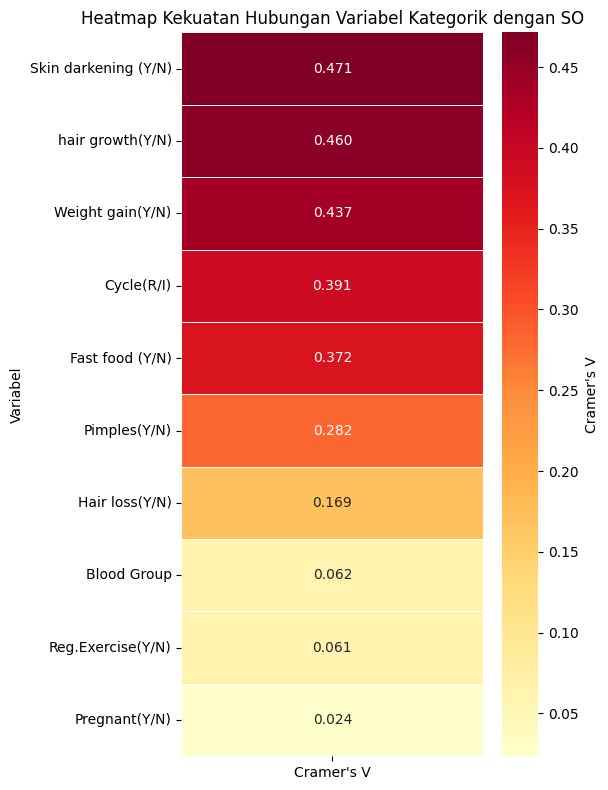

In [ ]:
# visualisasi data heatmap

# Urutkan berdasarkan nilai Cramer's V
heatmap_data = (
    cramers_results
    .sort_values("Cramer's V", ascending=False)
    .set_index("Variabel")[["Cramer's V"]]
)

# Buat heatmap
plt.figure(figsize=(6, 8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Cramer's V"}
)

plt.title(
    "Heatmap Kekuatan Hubungan Variabel Kategorik dengan SO"
)

plt.xlabel("")
plt.ylabel("Variabel")

plt.tight_layout()
plt.show()

### 12. Untuk setiap variabel independen bertipe numerik (skala pengukuran interval atau rasio), buatlah diagram pencar dengan sumbu datarnya adalah variabel independen dan sumbu tegaknya adalah variabel dependennya. Bagaimana hubungan antara dua variabel tersebut?

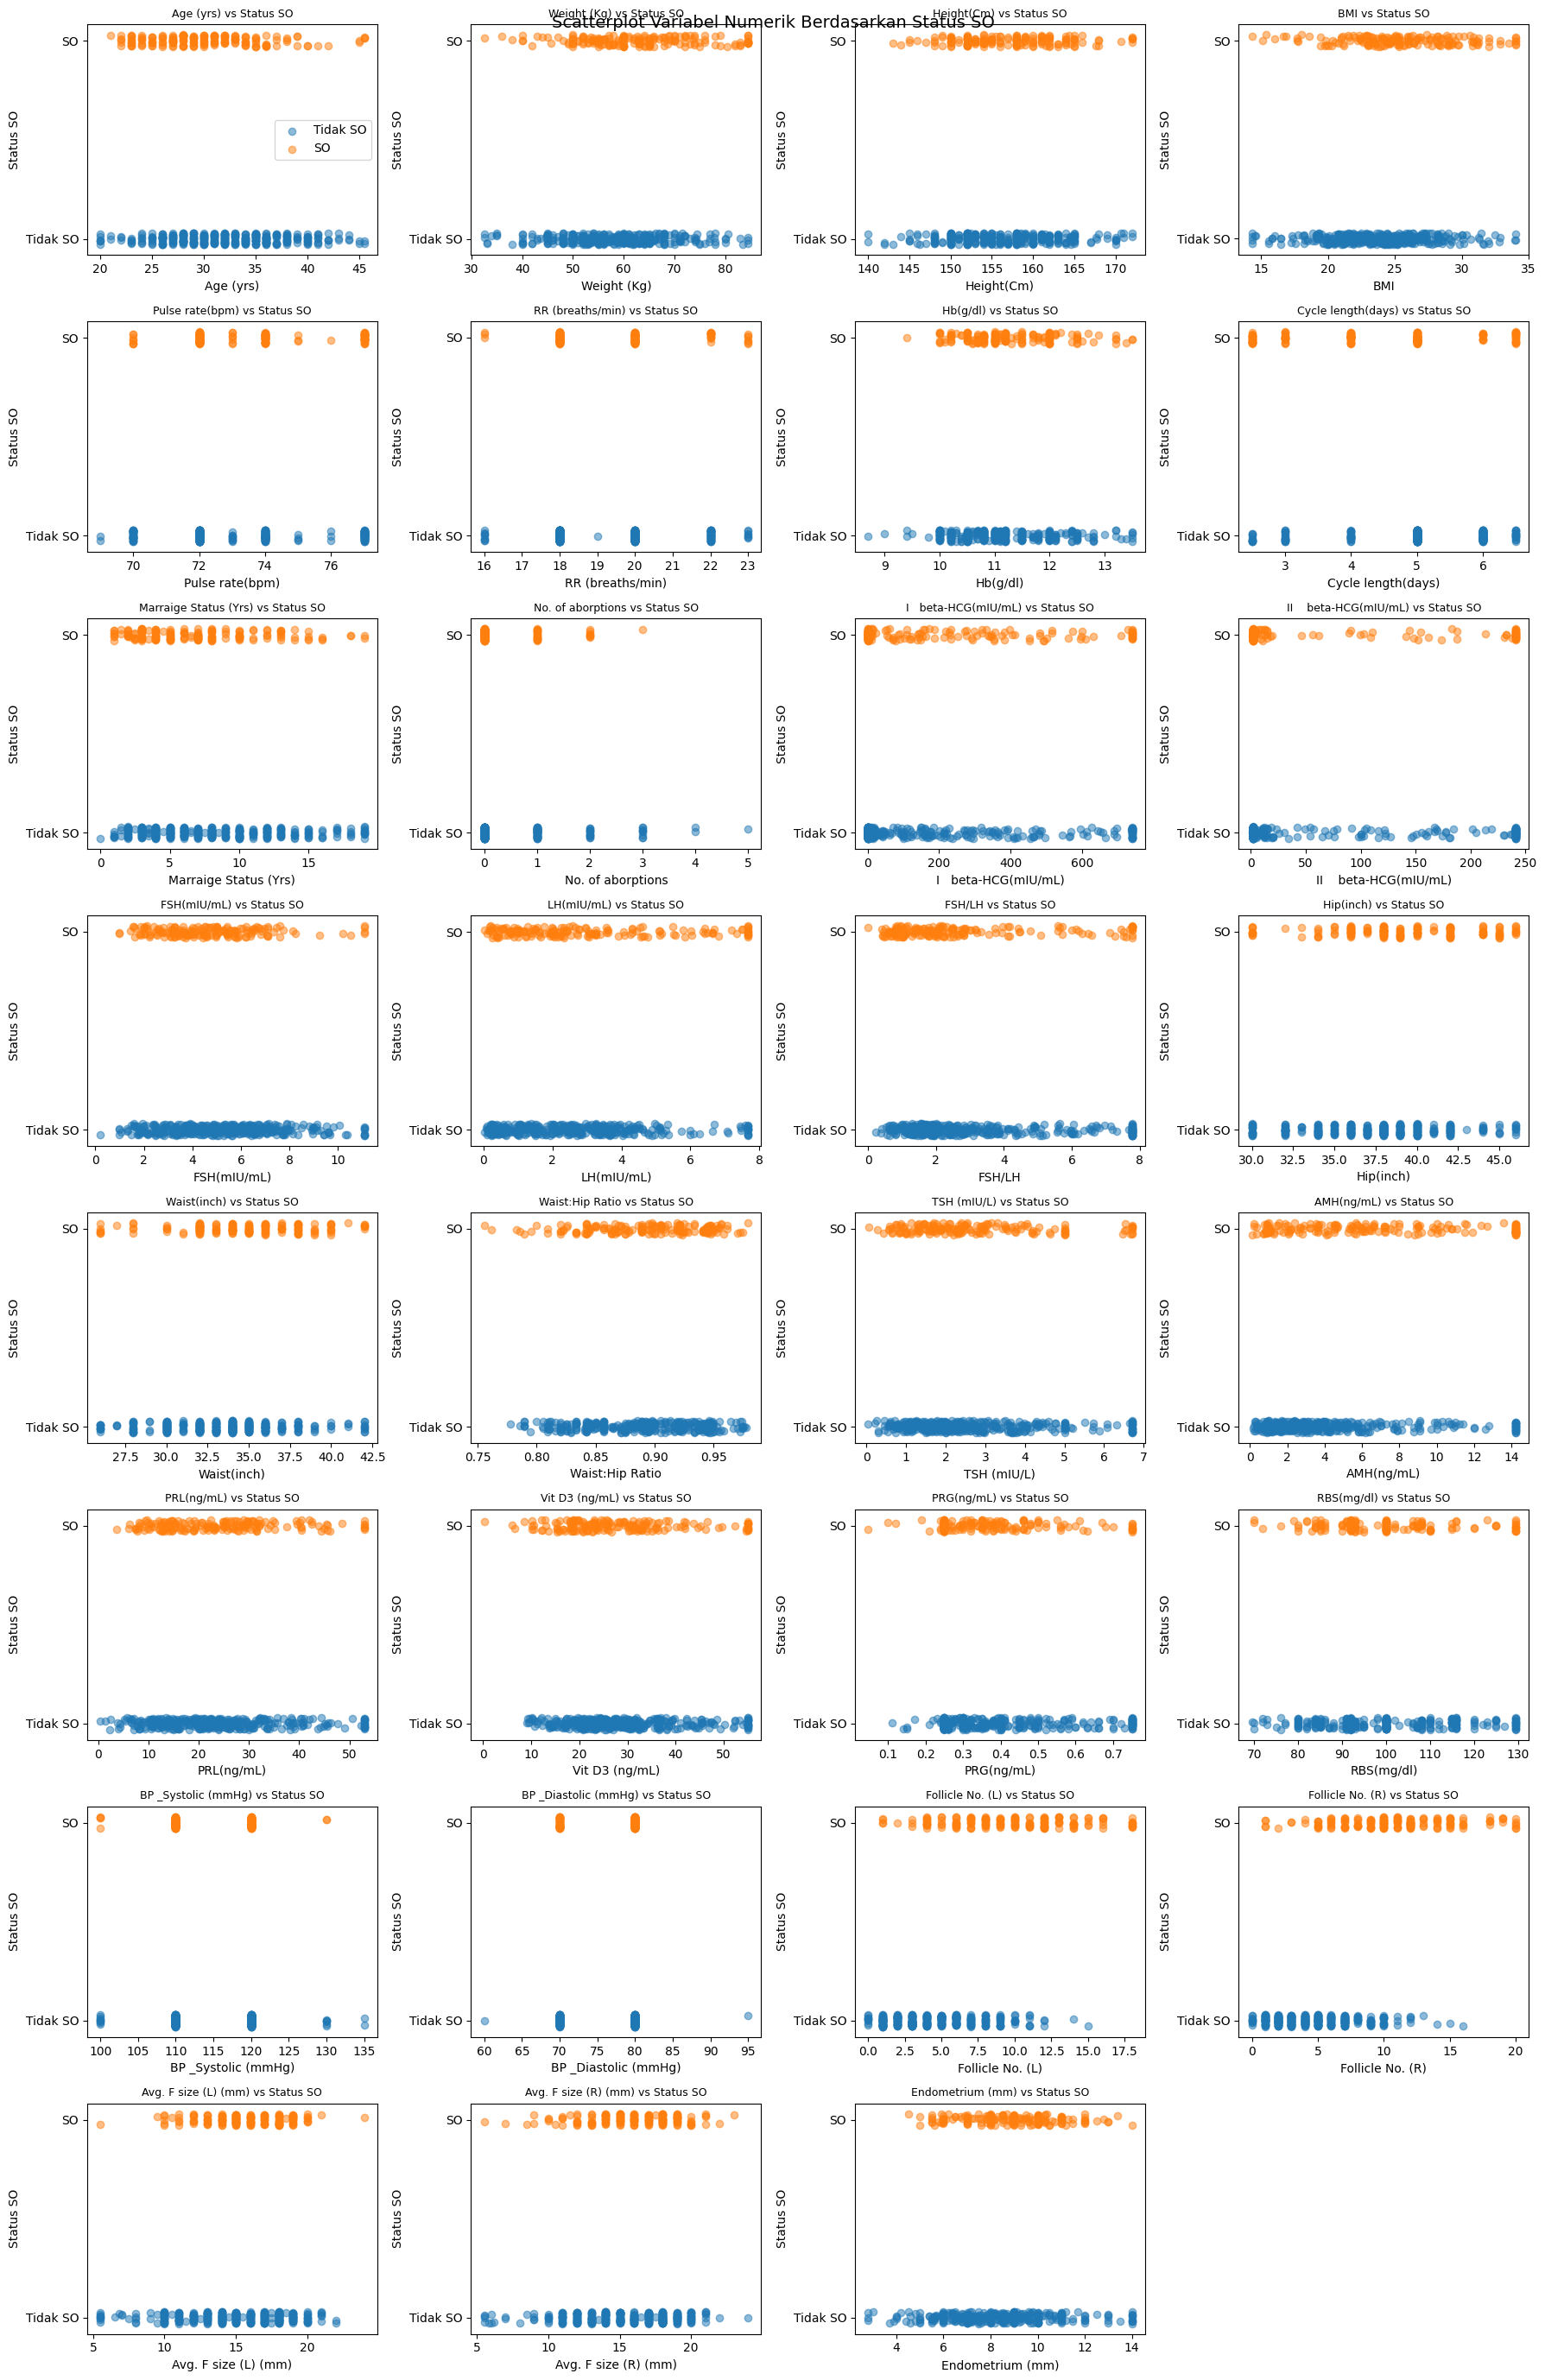

In [ ]:
# ============================================================
# SCATTERPLOT VARIABEL NUMERIK BERDASARKAN STATUS SO
# SO = 0 -> Tidak SO
# SO = 1 -> SO
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import math

n_cols = 4

n_rows = math.ceil(
    len(numeric_cols) / n_cols
)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, n_rows * 3.5)
)

axes = np.array(axes).flatten()

np.random.seed(42)

for i, col in enumerate(numeric_cols):

    # Data Tidak SO
    data_tidak_so = dataSO[
        dataSO["SO (Y/N)"] == 0
    ]

    x_tidak_so = data_tidak_so[col]

    y_tidak_so = np.random.uniform(
        -0.03,
        0.03,
        size=len(x_tidak_so)
    )

    # Data SO
    data_so = dataSO[
        dataSO["SO (Y/N)"] == 1
    ]

    x_so = data_so[col]

    y_so = 1 + np.random.uniform(
        -0.03,
        0.03,
        size=len(x_so)
    )

    # Scatter Tidak SO
    axes[i].scatter(
        x_tidak_so,
        y_tidak_so,
        alpha=0.5,
        label="Tidak SO"
    )

    # Scatter SO
    axes[i].scatter(
        x_so,
        y_so,
        alpha=0.5,
        label="SO"
    )

    axes[i].set_title(
        f"{col} vs Status SO",
        fontsize=9
    )

    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Status SO")

    axes[i].set_yticks([0, 1])
    axes[i].set_yticklabels([
        "Tidak SO",
        "SO"
    ])

# Matikan subplot yang tidak terpakai
for j in range(
    len(numeric_cols),
    len(axes)
):
    axes[j].axis("off")

# Legend cukup satu kali
axes[0].legend()

plt.suptitle(
    "Scatterplot Variabel Numerik Berdasarkan Status SO",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [ ]:
# INDEPENDENT SAMPLES T-TEST
# Numerik vs target kategorik biner (0 = Tidak SO, 1 = SO)

from scipy.stats import ttest_ind
ttest_results = []
for col in numeric_cols:

    # Data kelompok Tidak SO
    group_0 = dataSO.loc[dataSO[target] == 0, col].dropna()

    # Data kelompok SO
    group_1 = dataSO.loc[dataSO[target] == 1, col].dropna()

    # Welch's Independent Samples t-test
    t_stat, p_value = ttest_ind(group_0,group_1,equal_var=False)

    ttest_results.append({
        "Variabel": col,
        "Mean Tidak SO": group_0.mean(),
        "Mean SO": group_1.mean(),
        "t-statistic": t_stat,
        "p-value": p_value
    })
ttest_results = pd.DataFrame(ttest_results)

# Keputusan berdasarkan alpha 5%
ttest_results["Keputusan"] = np.where(
    ttest_results["p-value"] < 0.05,
    "Ada perbedaan rata-rata",
    "Tidak ada perbedaan rata-rata")
display(
    ttest_results
    .sort_values("p-value")
    .round(4))

# Variabel numerik dengan p-value < 0,05 menunjukkan adanya perbedaan rata-rata yang signifikan antara pasien Tidak SO dan SO,
# sehingga variabel tersebut berkaitan dengan status SO.

,Variabel,Mean Tidak SO,Mean SO,t-statistic,p-value,Keputusan
27,Follicle No. (R),4.6374,10.7627,-17.5686,0.0000,Ada perbedaan rata-rata
26,Follicle No. (L),4.3516,9.6893,-15.6716,0.0000,Ada perbedaan rata-rata
19,AMH(ng/mL),4.3168,6.6824,-5.9480,0.0000,Ada perbedaan rata-rata
7,Cycle length(days),5.0426,4.4463,5.6270,0.0000,Ada perbedaan rata-rata
1,Weight (Kg),57.9442,62.6424,-4.7205,0.0000,Ada perbedaan rata-rata
3,BMI,23.7444,25.3926,-4.5214,0.0000,Ada perbedaan rata-rata
0,Age (yrs),32.0549,30.1045,4.0433,0.0001,Ada perbedaan rata-rata
15,Hip(inch),37.5769,38.9605,-3.9303,0.0001,Ada perbedaan rata-rata
16,Waist(inch),33.4203,34.6384,-3.8585,0.0001,Ada perbedaan rata-rata
28,Avg. F size (L) (mm),14.8030,15.7006,-3.2694,0.0012,Ada perbedaan rata-rata


### 13. Membagi dataset menjadi data train dan data test dengan perbandingan 80:20.

In [ ]:
# ============================================================
# 4.1 PEMBAGIAN DATA TRAINING DAN DATA TESTING
# ============================================================

from sklearn.model_selection import train_test_split

# Variabel dependen
target = "SO (Y/N)"

# Variabel independen
X = dataSO.drop(
    columns=[
        "Sl. No",
        "Patient File No.",
        "SO (Y/N)"
    ]
)

# Variabel dependen
y = dataSO["SO (Y/N)"]

In [ ]:
# bagi data 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    train_size=0.80,
    stratify=y,
    random_state=42
)

# jumlah data
print("Jumlah data awal   :", len(dataSO))
print("Jumlah data training:", len(X_train))
print("Jumlah data testing :", len(X_test))


Jumlah data awal   : 541
Jumlah data training: 432
Jumlah data testing : 109


### 14.  Periksa data training, apakah persentase dari masing-masing kategori variabel dependennya seimbang? Jika tidak seimbang, apa yang harus dilakukan?

Jika tidak seimbang, gunakan class_weight="balanced" pada model klasifikasi


In [ ]:
# cek persentase SO pada data training
print("Distribusi SO pada data training:")
print(y_train.value_counts())
print("\nPersentase SO pada data training:")
print((y_train.value_counts(normalize=True) * 100).round(2))

Distribusi SO pada data training:
SO (Y/N)
0    291
1    141
Name: count, dtype: int64

Persentase SO pada data training:
SO (Y/N)
0    67.36
1    32.64
Name: proportion, dtype: float64


In [ ]:
print("\nDistribusi SO pada data testing:")
print(y_test.value_counts())

print("\nPersentase SO pada data testing:")

print(
    (y_test.value_counts(normalize=True) * 100).round(2)
)


Distribusi SO pada data testing:
SO (Y/N)
0    73
1    36
Name: count, dtype: int64

Persentase SO pada data testing:
SO (Y/N)
0    66.97
1    33.03
Name: proportion, dtype: float64


### 15. Dengan menggunakan data training, buatlah model statistika untuk mengetahui hubungan antara variabel dependen dengan variabel-variabel independennya. Model apa yang kamu pakai? Carilah model terbaiknya!

In [ ]:
categorical_cols = [
    "Blood Group",
    "Cycle(R/I)",
    "Pregnant(Y/N)",
    "Weight gain(Y/N)",
    "hair growth(Y/N)",
    "Skin darkening (Y/N)",
    "Hair loss(Y/N)",
    "Pimples(Y/N)",
    "Fast food (Y/N)",
    "Reg.Exercise(Y/N)"
]

numeric_cols = [
    "Age (yrs)",
    "Weight (Kg)",
    "Height(Cm)",
    "BMI",
    "Pulse rate(bpm)",
    "RR (breaths/min)",
    "Hb(g/dl)",
    "Cycle length(days)",
    "Marraige Status (Yrs)",
    "No. of aborptions",
    "I   beta-HCG(mIU/mL)",
    "II    beta-HCG(mIU/mL)",
    "FSH(mIU/mL)",
    "LH(mIU/mL)",
    "FSH/LH",
    "Hip(inch)",
    "Waist(inch)",
    "Waist:Hip Ratio",
    "TSH (mIU/L)",
    "AMH(ng/mL)",
    "PRL(ng/mL)",
    "Vit D3 (ng/mL)",
    "PRG(ng/mL)",
    "RBS(mg/dl)",
    "BP _Systolic (mmHg)",
    "BP _Diastolic (mmHg)",
    "Follicle No. (L)",
    "Follicle No. (R)",
    "Avg. F size (L) (mm)",
    "Avg. F size (R) (mm)",
    "Endometrium (mm)"
]

In [ ]:
categorical_dummy_cols = [
    "Blood Group",
    "Cycle(R/I)"
]

X_train = pd.get_dummies(
    X_train,
    columns=categorical_dummy_cols,
    drop_first=True,
    dtype=int
)

X_test = pd.get_dummies(
    X_test,
    columns=categorical_dummy_cols,
    drop_first=True,
    dtype=int
)

In [ ]:
X_test = X_test.reindex(
    columns=X_train.columns,
    fill_value=0
)

Karena:
- BloodGroup punya banyak kategori → perlu dummy
- Cycle punya 2 kategori (2 dan 4) → perlu dummy
- variabel biner 0/1 → tidak perlu dummy

In [ ]:
# Scaling hanya untuk Logistic Regression
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# logistic regression

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=42
        )
    )
])

In [ ]:
# decission tree
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    class_weight="balanced",
    max_depth=7,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

In [ ]:
# bandingkan model menggunakan Cross-Validation
from sklearn.model_selection import StratifiedKFold, cross_validate

models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "auc": "roc_auc"
}

model_results = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    model_results.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1-score": scores["test_f1"].mean(),
        "AUC": scores["test_auc"].mean()
    })

model_results = pd.DataFrame(model_results)

display(
    model_results.round(4)
)

,Model,Accuracy,Precision,Recall,F1-score,AUC
0,Logistic Regression,0.8636,0.7682,0.8441,0.8029,0.9290
1,Decision Tree,0.7735,0.6492,0.7448,0.6879,0.8128


In [ ]:
# ============================================================
# PEMILIHAN MODEL TERBAIK
# ============================================================
model_results_sorted = model_results.sort_values(
    by=["F1-score", "AUC"],
    ascending=False
)

display(model_results_sorted.round(4))
best_model_name = model_results_sorted.iloc[0]["Model"]
print("Model terbaik:", best_model_name)

,Model,Accuracy,Precision,Recall,F1-score,AUC
0,Logistic Regression,0.8636,0.7682,0.8441,0.8029,0.9290
1,Decision Tree,0.7735,0.6492,0.7448,0.6879,0.8128


Model terbaik: Logistic Regression


In [ ]:
best_model = models[best_model_name]

best_model.fit(X_train,y_train)

print(f"{best_model_name} berhasil dilatih.")

Logistic Regression berhasil dilatih.


### 16. Lakukan evaluasi performa akhir menggunakan data testing dengan menerapkan model terbaik yang telah diperoleh, menggunakan metrik akurasi, presisi, recall, F1-score, AUC, dan kurva ROC. Jelaskan hasilnya.

In [ ]:
# ============================================================
# EVALUASI MODEL TERBAIK PADA DATA TESTING
# ============================================================
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

In [ ]:
# Accuracy, Precision, Recall, F1, AUC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)

recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

auc_score = roc_auc_score(y_test,y_prob)
hasil_evaluasi = pd.DataFrame({
    "Metrik": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "AUC"
    ],
    "Nilai": [
        accuracy,
        precision,
        recall,
        f1,
        auc_score
    ]})

hasil_evaluasi["Persentase (%)"] = (hasil_evaluasi["Nilai"] * 100)
display(hasil_evaluasi.round(4))

,Metrik,Nilai,Persentase (%)
0,Accuracy,0.8532,85.3211
1,Precision,0.7381,73.8095
2,Recall,0.8611,86.1111
3,F1-score,0.7949,79.4872
4,AUC,0.9277,92.7702


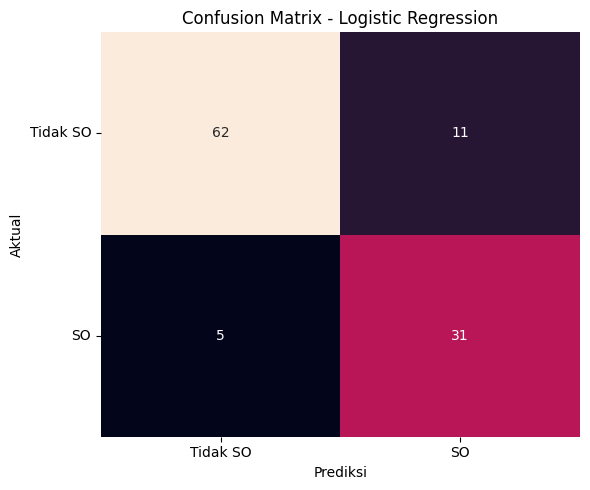

In [ ]:
# confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm,annot=True,fmt="d",cbar=False)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")

plt.xticks([0.5, 1.5],["Tidak SO", "SO"])
plt.yticks([0.5, 1.5],["Tidak SO", "SO"],rotation=0)

plt.tight_layout()
plt.show()

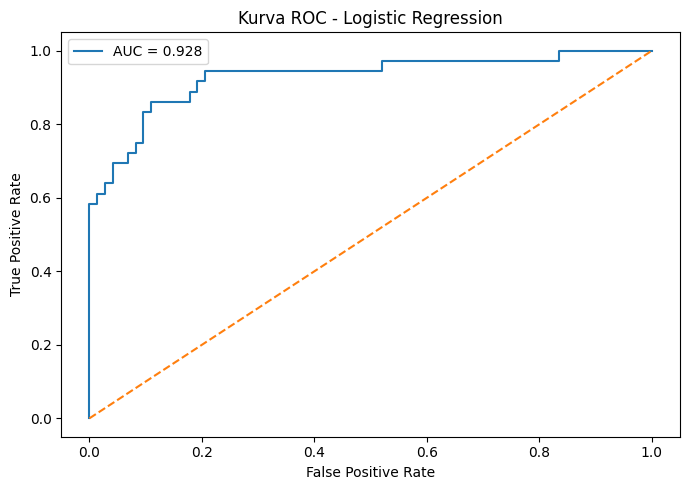

In [ ]:
# kurva ROC
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    f"Kurva ROC - {best_model_name}"
)

plt.legend()

plt.tight_layout()
plt.show()

### PEMILIHAN MODEL REGRESI LOGISTIK TERBAIK (FORWARD, BACKWARD, STEPWISE)

In [ ]:
# ============================================================
# REGRESI LOGISTIK BINER MULTIPLE
# ============================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm

# Pastikan seluruh X berbentuk numerik
X_train_sm = X_train.astype(float)

# Tambahkan intercept
X_train_sm = sm.add_constant(X_train_sm,has_constant="add")

# Model penuh
model_full = sm.Logit(y_train,X_train_sm).fit()
print(model_full.summary())

         Current function value: 0.181982
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:               SO (Y/N)   No. Observations:                  432
Model:                          Logit   Df Residuals:                      384
Method:                           MLE   Df Model:                           47
Date:                Thu, 13 Aug 2026   Pseudo R-squ.:                  0.7119
Time:                        15:11:49   Log-Likelihood:                -78.616
converged:                      False   LL-Null:                       -272.85
Covariance Type:            nonrobust   LLR p-value:                 2.866e-55
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -1.3470     42.031     -0.032      0.974     -83.727      81.033
Age (yrs)                  0.

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:

# FORWARD SELECTION BERDASARKAN AIC
# Forward dimulai dari model kosong,
# kemudian variabel ditambahkan satu per satu berdasarkan AIC terkecil.

def forward_selection(X, y):
    selected = []
    remaining = list(X.columns)
    # Model kosong hanya intercept
    X_null = sm.add_constant(
        pd.DataFrame(index=X.index),
        has_constant="add")
    current_model = sm.Logit(
        y,
        X_null
    ).fit(disp=0)

    current_aic = current_model.aic

    while remaining:
        candidates = []
        for col in remaining:
            cols = selected + [col]
            X_candidate = sm.add_constant(
                X[cols],
                has_constant="add")
            model = sm.Logit(
                y,
                X_candidate).fit(disp=0)
            candidates.append(
                (model.aic, col, model))
        candidates.sort(
            key=lambda x: x[0])

        best_aic, best_col, best_model = candidates[0]

        # Tambahkan jika AIC membaik
        if best_aic < current_aic:
            selected.append(best_col)
            remaining.remove(best_col)
            current_aic = best_aic
        else:
            break

    X_final = sm.add_constant(
        X[selected],
        has_constant="add")
    final_model = sm.Logit(
        y,
        X_final
    ).fit(disp=0)

    return final_model, selected

In [ ]:
model_forward, vars_forward = forward_selection(X_train,y_train)

print("Variabel Forward:")
print(vars_forward)

print("\nAIC Forward:")
print(model_forward.aic)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

Variabel Forward:
['Follicle No. (R)', 'hair growth(Y/N)', 'Weight gain(Y/N)', 'Cycle(R/I)_4.0', 'Skin darkening (Y/N)', 'Marraige Status (Yrs)', 'Pimples(Y/N)', 'Follicle No. (L)', 'RBS(mg/dl)', 'BP _Diastolic (mmHg)', 'Blood Group_14', 'Fast food (Y/N)']

AIC Forward:
205.95502158104802


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
print("Converged :", model_forward.mle_retvals["converged"])
print("AIC       :", model_forward.aic)

Converged : True
AIC       : 205.95502158104802


In [ ]:
# ============================================================
# BACKWARD ELIMINATION BERDASARKAN AIC
# ============================================================

def backward_selection(X, y):

    selected = list(X.columns)

    while len(selected) > 1:

        results = []

        for col in selected:

            cols = [
                c for c in selected
                if c != col
            ]

            X_candidate = sm.add_constant(
                X[cols],
                has_constant="add"
            )

            model = sm.Logit(
                y,
                X_candidate
            ).fit(disp=0)

            results.append(
                (model.aic, col, model)
            )

        results.sort(
            key=lambda x: x[0]
        )

        best_aic, remove_col, best_model = results[0]

        # AIC model sekarang
        X_current = sm.add_constant(
            X[selected],
            has_constant="add"
        )

        current_model = sm.Logit(
            y,
            X_current
        ).fit(disp=0)

        current_aic = current_model.aic

        # Hapus jika AIC membaik
        if best_aic < current_aic:

            selected.remove(remove_col)

        else:
            break

    X_final = sm.add_constant(
        X[selected],
        has_constant="add"
    )

    final_model = sm.Logit(
        y,
        X_final
    ).fit(disp=0)

    return final_model, selected

In [ ]:
model_backward, vars_backward = backward_selection(
    X_train,
    y_train
)

print("Variabel Backward:")
print(vars_backward)

print("\nAIC Backward:")
print(model_backward.aic)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

Variabel Backward:
['Cycle length(days)', 'Marraige Status (Yrs)', 'Waist(inch)', 'TSH (mIU/L)', 'RBS(mg/dl)', 'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Pimples(Y/N)', 'BP _Diastolic (mmHg)', 'Follicle No. (L)', 'Follicle No. (R)', 'Endometrium (mm)', 'Blood Group_14', 'Cycle(R/I)_4.0']

AIC Backward:
206.30586481137678


In [ ]:
# ============================================================
# STEPWISE SELECTION BERDASARKAN AIC
# ============================================================

def stepwise_selection(X, y):
    selected = []
    remaining = list(X.columns)
    improved = True
    while improved:
        improved = False
        # ----------------------------------------------------
        # FORWARD
        # ----------------------------------------------------

        candidates = []

        for col in remaining:

            cols = selected + [col]

            X_candidate = sm.add_constant(
                X[cols],
                has_constant="add"
            )

            model = sm.Logit(
                y,
                X_candidate
            ).fit(disp=0)

            candidates.append(
                (model.aic, col)
            )

        if candidates:

            candidates.sort(
                key=lambda x: x[0]
            )

            best_aic, best_col = candidates[0]

            if len(selected) == 0:

                current_aic = sm.Logit(
                    y,
                    sm.add_constant(
                        pd.DataFrame(index=X.index),
                        has_constant="add"
                    )
                ).fit(disp=0).aic

            else:

                current_aic = sm.Logit(
                    y,
                    sm.add_constant(
                        X[selected],
                        has_constant="add"
                    )
                ).fit(disp=0).aic

            if best_aic < current_aic:

                selected.append(best_col)
                remaining.remove(best_col)
                improved = True

        # ----------------------------------------------------
        # BACKWARD
        # ----------------------------------------------------

        if len(selected) > 1:

            current_model = sm.Logit(
                y,
                sm.add_constant(
                    X[selected],
                    has_constant="add"
                )
            ).fit(disp=0)

            current_aic = current_model.aic

            candidates = []

            for col in selected:

                cols = [
                    c for c in selected
                    if c != col
                ]

                model = sm.Logit(
                    y,
                    sm.add_constant(
                        X[cols],
                        has_constant="add"
                    )
                ).fit(disp=0)

                candidates.append(
                    (model.aic, col)
                )

            candidates.sort(
                key=lambda x: x[0]
            )

            best_aic, remove_col = candidates[0]

            if best_aic < current_aic:

                selected.remove(remove_col)
                remaining.append(remove_col)

                improved = True

    X_final = sm.add_constant(
        X[selected],
        has_constant="add"
    )

    final_model = sm.Logit(
        y,
        X_final
    ).fit(disp=0)

    return final_model, selected

In [ ]:
model_stepwise, vars_stepwise = stepwise_selection(
    X_train,
    y_train
)

print("Variabel Stepwise:")
print(vars_stepwise)

print("\nAIC Stepwise:")
print(model_stepwise.aic)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

Variabel Stepwise:
['Follicle No. (R)', 'hair growth(Y/N)', 'Weight gain(Y/N)', 'Cycle(R/I)_4.0', 'Skin darkening (Y/N)', 'Marraige Status (Yrs)', 'Pimples(Y/N)', 'Follicle No. (L)', 'RBS(mg/dl)', 'BP _Diastolic (mmHg)', 'Blood Group_14', 'Fast food (Y/N)']

AIC Stepwise:
205.95502158104802


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
# ============================================================
# PERBANDINGAN MODEL
# ============================================================

model_comparison = pd.DataFrame({
    "Metode": [
        "Forward",
        "Backward",
        "Stepwise"
    ],
    "Jumlah Variabel": [
        len(vars_forward),
        len(vars_backward),
        len(vars_stepwise)
    ],
    "AIC": [
        model_forward.aic,
        model_backward.aic,
        model_stepwise.aic
    ],
    "BIC": [
        model_forward.bic,
        model_backward.bic,
        model_stepwise.bic
    ]
})

display(
    model_comparison.sort_values(
        "AIC"
    ).round(4)
)

,Metode,Jumlah Variabel,AIC,BIC
0,Forward,12,205.9550,258.8446
2,Stepwise,12,205.9550,258.8446
1,Backward,15,206.3059,271.4007


In [ ]:
# ============================================================
# MODEL TERBAIK
# ============================================================

best_row = model_comparison.loc[
    model_comparison["AIC"].idxmin()]

print("Model terbaik :", best_row["Metode"])
print("AIC terkecil  :", round(best_row["AIC"], 4))

Model terbaik : Forward
AIC terkecil  : 205.955


In [ ]:
best_method = best_row["Metode"]

if best_method == "Forward":
    best_logit = model_forward
    best_vars = vars_forward

elif best_method == "Backward":
    best_logit = model_backward
    best_vars = vars_backward

else:
    best_logit = model_stepwise
    best_vars = vars_stepwise

print("Variabel model terbaik:")
print(best_vars)

print("\nRingkasan Model:")
print(best_logit.summary())

Variabel model terbaik:
['Follicle No. (R)', 'hair growth(Y/N)', 'Weight gain(Y/N)', 'Cycle(R/I)_4.0', 'Skin darkening (Y/N)', 'Marraige Status (Yrs)', 'Pimples(Y/N)', 'Follicle No. (L)', 'RBS(mg/dl)', 'BP _Diastolic (mmHg)', 'Blood Group_14', 'Fast food (Y/N)']

Ringkasan Model:
                           Logit Regression Results                           
Dep. Variable:               SO (Y/N)   No. Observations:                  432
Model:                          Logit   Df Residuals:                      419
Method:                           MLE   Df Model:                           12
Date:                Thu, 13 Aug 2026   Pseudo R-squ.:                  0.6702
Time:                        15:13:29   Log-Likelihood:                -89.978
converged:                       True   LL-Null:                       -272.85
Covariance Type:            nonrobust   LLR p-value:                 6.668e-71
                            coef    std err          z      P>|z|      [0.025      0.97

In [ ]:
# ============================================================
# UJI SIMULTAN - LIKELIHOOD RATIO TEST
# ============================================================

X_null = sm.add_constant(pd.DataFrame(index=X_train.index),has_constant="add")

null_model = sm.Logit(
    y_train,
    X_null
).fit(disp=0)

LR = 2 * (
    best_logit.llf -
    null_model.llf
)

df_LR = best_logit.df_model

from scipy.stats import chi2

p_LR = chi2.sf(
    LR,
    df_LR
)

print("Likelihood Ratio Test")
print("Chi-Square :", round(LR, 4))
print("df         :", int(df_LR))
print("p-value    :", round(p_LR, 4))

Likelihood Ratio Test
Chi-Square : 365.7403
df         : 12
p-value    : 0.0


In [ ]:
# ============================================================
# UJI PARSIAL - WALD TEST
# ============================================================

hasil_wald = pd.DataFrame({
    "Variabel": best_logit.params.index,
    "Koefisien": best_logit.params.values,
    "Std Error": best_logit.bse.values,
    "z": best_logit.tvalues.values,
    "p-value": best_logit.pvalues.values
})

hasil_wald["Keputusan"] = np.where(
    hasil_wald["p-value"] < 0.05,
    "Signifikan",
    "Tidak signifikan"
)

display(
    hasil_wald.round(4)
)

,Variabel,Koefisien,Std Error,z,p-value,Keputusan
0,const,-3.9129,3.6338,-1.0768,0.2816,Tidak signifikan
1,Follicle No. (R),0.4451,0.0740,6.0133,0.0000,Signifikan
2,hair growth(Y/N),1.7599,0.4614,3.8146,0.0001,Signifikan
3,Weight gain(Y/N),1.5263,0.4318,3.5352,0.0004,Signifikan
4,Cycle(R/I)_4.0,1.9300,0.4513,4.2768,0.0000,Signifikan
5,Skin darkening (Y/N),1.3605,0.4320,3.1495,0.0016,Signifikan
6,Marraige Status (Yrs),-0.1435,0.0488,-2.9401,0.0033,Signifikan
7,Pimples(Y/N),0.9877,0.4110,2.4032,0.0163,Signifikan
8,Follicle No. (L),0.1615,0.0726,2.2252,0.0261,Signifikan
9,RBS(mg/dl),0.0267,0.0162,1.6458,0.0998,Tidak signifikan


In [ ]:
# ============================================================
# ODDS RATIO MODEL TERBAIK
# ============================================================

conf = best_logit.conf_int()

hasil_or = pd.DataFrame({
    "Variabel": best_logit.params.index,
    "Koefisien": best_logit.params.values,
    "Odds Ratio": np.exp(
        best_logit.params.values
    ),
    "CI Lower": np.exp(conf[0].values),
    "CI Upper": np.exp(conf[1].values),
    "p-value": best_logit.pvalues.values
})

display(
    hasil_or.round(4)
)

,Variabel,Koefisien,Odds Ratio,CI Lower,CI Upper,p-value
0,const,-3.9129,0.0200,0.0000,24.7594,0.2816
1,Follicle No. (R),0.4451,1.5607,1.3499,1.8044,0.0000
2,hair growth(Y/N),1.7599,5.8119,2.3529,14.3558,0.0001
3,Weight gain(Y/N),1.5263,4.6013,1.9741,10.7250,0.0004
4,Cycle(R/I)_4.0,1.9300,6.8895,2.8449,16.6844,0.0000
5,Skin darkening (Y/N),1.3605,3.8982,1.6717,9.0902,0.0016
6,Marraige Status (Yrs),-0.1435,0.8663,0.7873,0.9533,0.0033
7,Pimples(Y/N),0.9877,2.6851,1.1998,6.0090,0.0163
8,Follicle No. (L),0.1615,1.1753,1.0194,1.3550,0.0261
9,RBS(mg/dl),0.0267,1.0270,0.9949,1.0602,0.0998


In [ ]:
# ============================================================
# HOSMER-LEMESHOW
# ============================================================

from scipy.stats import chi2

X_best = sm.add_constant(
    X_train[best_vars],
    has_constant="add"
)

prob = best_logit.predict(X_best)

hl_data = pd.DataFrame({
    "y": y_train.values,
    "prob": prob.values
})

hl_data["group"] = pd.qcut(
    hl_data["prob"],
    q=10,
    duplicates="drop"
)

hl_table = hl_data.groupby(
    "group",
    observed=False
).agg(
    observed_0=("y", lambda x: (x == 0).sum()),
    observed_1=("y", lambda x: (x == 1).sum()),
    expected_1=("prob", "sum")
)

hl_table["n"] = (
    hl_table["observed_0"] +
    hl_table["observed_1"]
)

hl_table["expected_0"] = (
    hl_table["n"] -
    hl_table["expected_1"]
)

HL = (
    (
        (hl_table["observed_0"] -
         hl_table["expected_0"]) ** 2
        / hl_table["expected_0"]
    )
    +
    (
        (hl_table["observed_1"] -
         hl_table["expected_1"]) ** 2
        / hl_table["expected_1"]
    )
).sum()

df_HL = len(hl_table) - 2

p_HL = chi2.sf(
    HL,
    df_HL
)

print("Hosmer-Lemeshow Test")
print("Chi-Square :", round(HL, 4))
print("df         :", df_HL)
print("p-value    :", round(p_HL, 4))

Hosmer-Lemeshow Test
Chi-Square : 21.0611
df         : 8
p-value    : 0.007


#### mencoba prediksi data baru

In [ ]:
# ============================================================
# PREDIKSI DATA PASIEN BARU
# ============================================================

data_baru = pd.DataFrame([{
    "Age": 30,
    "Weight": 65,
    "Height": 160,
    "BMI": 25.39,
    "BloodGroup": 15,
    "PulseRate": 76,
    "RR": 20,
    "Hb": 11.5,
    "Cycle": 4,
    "CycleLength": 6,
    "MarriageStatus": 5,
    "Pregnant": 0,
    "Abortions": 0,
    "BetaHCG1": 2.0,
    "BetaHCG2": 2.0,
    "FSH": 6.0,
    "LH": 5.0,
    "FSHLH": 1.2,
    "Hip": 38,
    "Waist": 32,
    "WaistHipRatio": 0.84,
    "TSH": 2.0,
    "AMH": 6.5,
    "PRL": 20,
    "VitD3": 30,
    "PRG": 0.4,
    "RBS": 95,
    "WeightGain": 1,
    "HairGrowth": 1,
    "SkinDarkening": 1,
    "HairLoss": 0,
    "Pimples": 1,
    "FastFood": 1,
    "RegExercise": 0,
    "BPSystolic": 120,
    "BPDiastolic": 80,
    "FollicleNoL": 10,
    "FollicleNoR": 11,
    "AvgFSizeL": 10,
    "AvgFSizeR": 11,
    "Endometrium": 8
}])

In [ ]:
# Lakukan dummy encoding seperti data training
data_baru = pd.get_dummies(
    data_baru,
    columns=["BloodGroup", "Cycle"],
    drop_first=True,
    dtype=int
)

In [ ]:
# Samakan kolom dengan data training
data_baru = data_baru.reindex(
    columns=X_train.columns,
    fill_value=0
)

In [ ]:
# prediksi menggunakan model terbaik
prediksi = best_model.predict(data_baru)

print("Hasil prediksi:", prediksi[0])

Hasil prediksi: 0


In [ ]:
probabilitas = best_model.predict_proba(
    data_baru
)[0]

hasil_prediksi = pd.DataFrame({
    "Prediksi": [
        "SO" if prediksi[0] == 1 else "Tidak SO"
    ],
    "Probabilitas Tidak SO (%)": [
        probabilitas[0] * 100
    ],
    "Probabilitas SO (%)": [
        probabilitas[1] * 100
    ]
})

display(
    hasil_prediksi.round(2)
)

,Prediksi,Probabilitas Tidak SO (%),Probabilitas SO (%)
0,Tidak SO,100.0,0.0


#### BOBOT MODEL

In [ ]:
# Ambil model Logistic Regression dari pipeline
lr_model = best_model.named_steps["model"]

# Ambil koefisien
koefisien = lr_model.coef_[0]

# Ambil nama variabel
nama_variabel = X_train.columns

In [ ]:
bobot_model = pd.DataFrame({
    "Variabel": X_train.columns,
    "Koefisien": lr_model.coef_[0]
})

bobot_model["Odds Ratio"] = np.exp(
    bobot_model["Koefisien"]
)

bobot_model["Arah"] = np.where(
    bobot_model["Koefisien"] > 0,
    "Positif",
    np.where(
        bobot_model["Koefisien"] < 0,
        "Negatif",
        "Tidak ada arah"
    )
)

bobot_model = bobot_model.sort_values(
    "Koefisien",
    key=lambda x: x.abs(),
    ascending=False
)

display(
    bobot_model.round(4)
)

,Variabel,Koefisien,Odds Ratio,Arah
35,Follicle No. (R),1.8504,6.3624,Positif
26,hair growth(Y/N),0.8831,2.4185,Positif
27,Skin darkening (Y/N),0.7346,2.0847,Positif
46,Cycle(R/I)_4.0,0.6622,1.9391,Positif
25,Weight gain(Y/N),0.5867,1.7981,Positif
8,Marraige Status (Yrs),-0.5813,0.5592,Negatif
29,Pimples(Y/N),0.5078,1.6616,Positif
34,Follicle No. (L),0.4609,1.5855,Positif
24,RBS(mg/dl),0.4346,1.5444,Positif
4,Pulse rate(bpm),0.3629,1.4376,Positif
